## Import Library

In [ ]:
!pip install Sastrawi
!pip install accelerate datasets
!pip install stanza -q
!pip install wordcloud plotly -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 52.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 40.5 MB/s eta 0:00:00


In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import numpy as np
import re
import time
import random
import os
import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

import stanza
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer

import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from datasets import Dataset, DatasetDict
import nltk
from tqdm.auto import tqdm
from collections import Counter
from transformers import DataCollatorWithPadding
from transformers import pipeline

tqdm.pandas()

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Web Scrapping

### Detik.com

In [ ]:
NON_SEPAKBOLA_QUERIES = [
    'motogp',
    'formula 1',
    'f1',
    'bulutangkis',
    'bwf',
    'all england',
    'basket',
    'nba',
    'ibl',
    'voli',
    'proliga',
    'tenis',
    'atp',
    'wta',
    'tinju',
    'ufc',
    'mma',
    'balap',
    'olimpiade',
    'sea games',
    'asian games',
    'renang',
    'atletik',
    'golf',
    'biliar',
    'panjat tebing',
    'taekwondo',
    'karate'
]

In [ ]:
HEADERS = {
    'User-Agent': (
        'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
        'AppleWebKit/537.36 (KHTML, like Gecko) '
        'Chrome/120.0.0.0 Safari/537.36'
    )
}

DETIK_QUERIES = {
    'liga_inggris': 'liga inggris',
    'liga_indonesia': 'liga indonesia',
    'liga_spanyol': 'liga spanyol',
    'liga_italia': 'liga italia',

}

DETIK_FILTER = {
    'liga_inggris': '/liga-inggris/',
    'liga_indonesia': '/liga-indonesia/',
    'liga_spanyol': '/liga-spanyol/',
    'liga_italia': '/liga-italia/',

}

In [ ]:
def scrape_detik_search(
    query,
    keyword=None,
    max_pages=30,
    max_urls=120
):

    article_urls = set()

    for page in range(1, max_pages + 1):

        search_url = (
            "https://www.detik.com/search/searchall"
            f"?query={query}"
            "&siteid=2"
            "&source_kanal=true"
            f"&page={page}"
        )

        try:
            r = requests.get(
                search_url,
                headers=HEADERS,
                timeout=15
            )

            soup = BeautifulSoup(r.text, "html.parser")

            for a in soup.find_all("a", href=True):

                href = a["href"]

                if not href.startswith("https://sport.detik.com"):
                    continue

                if "/d-" not in href:
                    continue

                if keyword and keyword not in href:
                    continue

                article_urls.add(href)

                # Berhenti jika URL sudah mencapai target
                if len(article_urls) >= max_urls:
                    print(f"Target {max_urls} URL tercapai")
                    return list(article_urls)

            print(f"Page {page} -> {len(article_urls)} URL unik")

            time.sleep(random.uniform(1, 2))

        except Exception as e:
            print(f"Error page {page}: {e}")

    return list(article_urls)

In [ ]:
def scrape_detik_article(url):

    try:
        r = requests.get(
            url,
            headers=HEADERS,
            timeout=15
        )

        soup = BeautifulSoup(r.text, 'html.parser')

        content_div = (
            soup.find('div', class_='detail__body')
            or soup.find('div', id='detikdetailtext')
        )

        if content_div:

            paragraphs = content_div.find_all('p')

            text = ' '.join(
                p.get_text(" ", strip=True)
                for p in paragraphs
            )

            if len(text) > 100:
                return text

    except Exception:
        pass

    return None

In [ ]:
detik_data = []

In [ ]:
for label, query in DETIK_QUERIES.items():

    print(f"\n {label}")

    urls = scrape_detik_search(
        query=query,
        keyword=DETIK_FILTER[label],
        max_pages=70
    )

    print(f"URL ditemukan: {len(urls)}")

    success = 0

    for url in tqdm(urls):

        text = scrape_detik_article(url)

        if text:

            detik_data.append({
                'teks': text,
                'media': 'detik.com',
                'label': label
            })

            success += 1

        time.sleep(random.uniform(0.5, 1.2))


 liga_inggris
Page 1 -> 3 URL unik
Page 2 -> 6 URL unik
Page 3 -> 13 URL unik
Page 4 -> 17 URL unik
Page 5 -> 18 URL unik
Page 6 -> 22 URL unik
Page 7 -> 26 URL unik
Page 8 -> 30 URL unik
Page 9 -> 38 URL unik
Page 10 -> 43 URL unik
Page 11 -> 49 URL unik
Page 12 -> 53 URL unik
Page 13 -> 59 URL unik
Page 14 -> 63 URL unik
Page 15 -> 68 URL unik
Page 16 -> 70 URL unik
Page 17 -> 75 URL unik
Page 18 -> 78 URL unik
Page 19 -> 79 URL unik
Page 20 -> 82 URL unik
Page 21 -> 86 URL unik
Page 22 -> 93 URL unik
Page 23 -> 98 URL unik
Page 24 -> 105 URL unik
Page 25 -> 111 URL unik
Page 26 -> 116 URL unik
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [03:46<00:00,  1.89s/it]



 liga_indonesia
Page 1 -> 1 URL unik
Page 2 -> 5 URL unik
Page 3 -> 9 URL unik
Page 4 -> 13 URL unik
Page 5 -> 16 URL unik
Page 6 -> 18 URL unik
Page 7 -> 19 URL unik
Page 8 -> 19 URL unik
Page 9 -> 22 URL unik
Page 10 -> 27 URL unik
Page 11 -> 29 URL unik
Page 12 -> 30 URL unik
Page 13 -> 32 URL unik
Page 14 -> 32 URL unik
Page 15 -> 33 URL unik
Page 16 -> 35 URL unik
Page 17 -> 37 URL unik
Page 18 -> 38 URL unik
Page 19 -> 38 URL unik
Page 20 -> 38 URL unik
Page 21 -> 41 URL unik
Page 22 -> 44 URL unik
Page 23 -> 45 URL unik
Page 24 -> 48 URL unik
Page 25 -> 50 URL unik
Page 26 -> 53 URL unik
Page 27 -> 56 URL unik
Page 28 -> 58 URL unik
Page 29 -> 60 URL unik
Page 30 -> 62 URL unik
Page 31 -> 63 URL unik
Page 32 -> 63 URL unik
Page 33 -> 65 URL unik
Page 34 -> 66 URL unik
Page 35 -> 68 URL unik
Page 36 -> 71 URL unik
Page 37 -> 72 URL unik
Page 38 -> 75 URL unik
Page 39 -> 77 URL unik
Page 40 -> 81 URL unik
Page 41 -> 81 URL unik
Page 42 -> 83 URL unik
Page 43 -> 85 URL unik
Page 4

100%|██████████| 120/120 [03:50<00:00,  1.92s/it]



 liga_spanyol
Page 1 -> 4 URL unik
Page 2 -> 5 URL unik
Page 3 -> 7 URL unik
Page 4 -> 10 URL unik
Page 5 -> 11 URL unik
Page 6 -> 17 URL unik
Page 7 -> 21 URL unik
Page 8 -> 23 URL unik
Page 9 -> 26 URL unik
Page 10 -> 28 URL unik
Page 11 -> 34 URL unik
Page 12 -> 35 URL unik
Page 13 -> 38 URL unik
Page 14 -> 40 URL unik
Page 15 -> 44 URL unik
Page 16 -> 48 URL unik
Page 17 -> 50 URL unik
Page 18 -> 51 URL unik
Page 19 -> 54 URL unik
Page 20 -> 60 URL unik
Page 21 -> 64 URL unik
Page 22 -> 72 URL unik
Page 23 -> 78 URL unik
Page 24 -> 84 URL unik
Page 25 -> 90 URL unik
Page 26 -> 98 URL unik
Page 27 -> 106 URL unik
Page 28 -> 110 URL unik
Page 29 -> 119 URL unik
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [03:45<00:00,  1.88s/it]



 liga_italia
Page 1 -> 3 URL unik
Page 2 -> 5 URL unik
Page 3 -> 7 URL unik
Page 4 -> 10 URL unik
Page 5 -> 13 URL unik
Page 6 -> 19 URL unik
Page 7 -> 21 URL unik
Page 8 -> 26 URL unik
Page 9 -> 33 URL unik
Page 10 -> 41 URL unik
Page 11 -> 50 URL unik
Page 12 -> 57 URL unik
Page 13 -> 59 URL unik
Page 14 -> 62 URL unik
Page 15 -> 68 URL unik
Page 16 -> 77 URL unik
Page 17 -> 83 URL unik
Page 18 -> 89 URL unik
Page 19 -> 98 URL unik
Page 20 -> 104 URL unik
Page 21 -> 107 URL unik
Page 22 -> 112 URL unik
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [03:48<00:00,  1.91s/it]


In [ ]:
non_urls = set()

for query in NON_SEPAKBOLA_QUERIES:

    print(f"\nSearch {query}")

    urls = scrape_detik_search(
        query=query,
        keyword=None,
        max_pages=3
    )

    non_urls.update(urls)

print(f"\nTotal URL non-sepakbola: {len(non_urls)}")


Search motogp
Page 1 -> 4 URL unik
Page 2 -> 11 URL unik
Page 3 -> 18 URL unik

Search formula 1
Page 1 -> 3 URL unik
Page 2 -> 3 URL unik
Page 3 -> 5 URL unik

Search f1
Page 1 -> 4 URL unik
Page 2 -> 6 URL unik
Page 3 -> 8 URL unik

Search bulutangkis
Page 1 -> 9 URL unik
Page 2 -> 18 URL unik
Page 3 -> 26 URL unik

Search bwf
Page 1 -> 9 URL unik
Page 2 -> 18 URL unik
Page 3 -> 26 URL unik

Search all england
Page 1 -> 8 URL unik
Page 2 -> 18 URL unik
Page 3 -> 28 URL unik

Search basket
Page 1 -> 6 URL unik
Page 2 -> 7 URL unik
Page 3 -> 13 URL unik

Search nba
Page 1 -> 5 URL unik
Page 2 -> 15 URL unik
Page 3 -> 20 URL unik

Search ibl
Page 1 -> 9 URL unik
Page 2 -> 17 URL unik
Page 3 -> 25 URL unik

Search voli
Page 1 -> 3 URL unik
Page 2 -> 8 URL unik
Page 3 -> 11 URL unik

Search proliga
Page 1 -> 4 URL unik
Page 2 -> 8 URL unik
Page 3 -> 12 URL unik

Search tenis
Page 1 -> 1 URL unik
Page 2 -> 3 URL unik
Page 3 -> 5 URL unik

Search atp
Page 1 -> 2 URL unik
Page 2 -> 3 URL un

In [ ]:
filtered_non_urls = []

for url in non_urls:

    if any([
        '/liga-inggris/' in url,
        '/liga-indonesia/' in url,
        '/liga-spanyol/' in url,
        '/liga-italia/' in url,
    ]):
        continue

    filtered_non_urls.append(url)

print("Non-sepakbola setelah filter:", len(filtered_non_urls))

Non-sepakbola setelah filter: 282


In [ ]:
TARGET_NON = 120
success = 0

for url in tqdm(filtered_non_urls):

    if success >= TARGET_NON:
        break

    text = scrape_detik_article(url)

    if text:

        detik_data.append({
            'teks': text,
            'media': 'detik.com',
            'label': 'olahraga_non_sepakbola'
        })

        success += 1

    time.sleep(random.uniform(0.5, 1.2))

print("Jumlah artikel non sepakbola :", success)

 52%|█████▏    | 146/282 [04:32<04:13,  1.87s/it]

Jumlah artikel non sepakbola : 120


In [ ]:
df_detik = pd.DataFrame(detik_data)

df_detik.drop_duplicates(
    subset=['teks'],
    inplace=True
)

df_detik.reset_index(
    drop=True,
    inplace=True
)

In [ ]:
df_detik['label'].value_counts()

,count
label,
olahraga_non_sepakbola,120
liga_italia,120
liga_spanyol,119
liga_indonesia,119
liga_inggris,117


In [ ]:
len(df_detik)

595

### Kompas.com

In [ ]:
KOMPAS_CATEGORY = {
    "liga_inggris": "https://bola.kompas.com/liga-inggris",
    "liga_indonesia": "https://bola.kompas.com/liga-indonesia",
    "liga_spanyol": "https://bola.kompas.com/liga-spanyol",
    "liga_italia": "https://bola.kompas.com/liga-italia",
}

In [ ]:
def scrape_kompas_category(base_url, max_pages=30, max_urls=120):

    article_urls = set()

    for page in range(1, max_pages + 1):

        if page == 1:
            url = base_url
        else:
            url = f"{base_url}/{page}"

        try:
            r = requests.get(
                url,
                headers=HEADERS,
                timeout=15
            )

            soup = BeautifulSoup(r.text, "html.parser")

            for a in soup.find_all("a", href=True):

                href = a.get("href")

                if not href:
                    continue

                if "kompas.com" not in href:
                    continue

                if "/read/" not in href:
                    continue

                if href in article_urls:
                    continue

                article_urls.add(href)

                if len(article_urls) >= max_urls:
                    print(f"Target {max_urls} URL tercapai")
                    return list(article_urls)

            print(f"Page {page} -> {len(article_urls)} URL")

            time.sleep(random.uniform(1,2))

        except Exception as e:
            print(f"Error page {page}: {e}")

    return list(article_urls)

In [ ]:
def scrape_kompas_search(
    query,
    max_pages=30,
    max_urls=120
):

    article_urls = set()

    for page in range(1, max_pages + 1):

        search_url = (
            "https://search.kompas.com/search"
            f"?q={query.replace(' ', '+')}"
            f"&page={page}"
        )

        try:
            r = requests.get(
                search_url,
                headers=HEADERS,
                timeout=15
            )

            soup = BeautifulSoup(r.text, "html.parser")

            for a in soup.find_all("a", href=True):

                href = a["href"]

                if "kompas.com" not in href:
                    continue

                if "/read/" not in href:
                    continue

                article_urls.add(href)

                if len(article_urls) >= max_urls:
                    print(f"Target {max_urls} URL tercapai")
                    return list(article_urls)

            print(f"Page {page} -> {len(article_urls)} URL unik")

            time.sleep(random.uniform(1, 2))

        except Exception as e:
            print(f"Error page {page}: {e}")

    return list(article_urls)

In [ ]:
def scrape_kompas_article(url):

    try:
        r = requests.get(
            url,
            headers=HEADERS,
            timeout=15
        )

        soup = BeautifulSoup(r.text, "html.parser")

        content_div = soup.find("div", class_="read__content")

        if not content_div:
            return None

        # Hapus elemen yang bukan isi artikel
        for tag in content_div.find_all([
            "script",
            "style",
            "iframe",
            "figure",
            "aside",
            "noscript",
            "svg",
        ]):
            tag.decompose()

        # Hapus widget foto
        for tag in content_div.find_all("div", class_="photo"):
            tag.decompose()

        paragraphs = []

        for p in content_div.find_all("p"):

            text = p.get_text(" ", strip=True)

            # Skip paragraf kosong
            if not text:
                continue

            # Skip "Baca juga"
            if text.startswith("Baca juga:"):
                continue

            paragraphs.append(text)

        text = " ".join(paragraphs)
        text = " ".join(text.split())

        if len(text) > 100:
            return text

    except Exception as e:
        print(e)

    return None

In [ ]:
kompas_data = []

In [ ]:
for label, base_url in KOMPAS_CATEGORY.items():

    print(f"\n{label}")

    urls = scrape_kompas_category(
        base_url,
        max_pages=70
    )

    print(f"URL ditemukan: {len(urls)}")

    success = 0

    for url in tqdm(urls):
        url += "?page=all"
        text = scrape_kompas_article(url)

        if text:

            kompas_data.append({
                "teks": text,
                "media": "kompas.com",
                "label": label
            })

            success += 1

        time.sleep(random.uniform(0.5, 1.2))


liga_inggris
Page 1 -> 41 URL
Page 2 -> 71 URL
Page 3 -> 101 URL
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [02:57<00:00,  1.48s/it]



liga_indonesia
Page 1 -> 41 URL
Page 2 -> 71 URL
Page 3 -> 101 URL
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [02:39<00:00,  1.33s/it]



liga_spanyol
Page 1 -> 41 URL
Page 2 -> 71 URL
Page 3 -> 101 URL
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [03:32<00:00,  1.77s/it]



liga_italia
Page 1 -> 41 URL
Page 2 -> 71 URL
Page 3 -> 101 URL
Target 120 URL tercapai
URL ditemukan: 120


100%|██████████| 120/120 [03:27<00:00,  1.73s/it]


In [ ]:
non_urls = set()

In [ ]:
for query in NON_SEPAKBOLA_QUERIES:

    print(f"\nSearch : {query}")

    urls = scrape_kompas_search(
        query=query,
        max_pages=4
    )

    non_urls.update(urls)

print(f"\nTotal URL non-sepakbola: {len(non_urls)}")


Search : motogp
Page 1 -> 21 URL unik
Page 2 -> 41 URL unik
Page 3 -> 61 URL unik
Page 4 -> 81 URL unik

Search : formula 1
Page 1 -> 20 URL unik
Page 2 -> 40 URL unik
Page 3 -> 60 URL unik
Page 4 -> 78 URL unik

Search : f1
Page 1 -> 3 URL unik
Page 2 -> 3 URL unik
Page 3 -> 3 URL unik
Page 4 -> 3 URL unik

Search : bulutangkis
Page 1 -> 20 URL unik
Page 2 -> 20 URL unik
Page 3 -> 20 URL unik
Page 4 -> 20 URL unik

Search : bwf
Page 1 -> 6 URL unik
Page 2 -> 6 URL unik
Page 3 -> 6 URL unik
Page 4 -> 6 URL unik

Search : all england
Page 1 -> 14 URL unik
Page 2 -> 14 URL unik
Page 3 -> 14 URL unik
Page 4 -> 14 URL unik

Search : basket
Page 1 -> 4 URL unik
Page 2 -> 4 URL unik
Page 3 -> 4 URL unik
Page 4 -> 4 URL unik

Search : nba
Page 1 -> 5 URL unik
Page 2 -> 5 URL unik
Page 3 -> 5 URL unik
Page 4 -> 5 URL unik

Search : ibl
Page 1 -> 3 URL unik
Page 2 -> 3 URL unik
Page 3 -> 3 URL unik
Page 4 -> 3 URL unik

Search : voli
Page 1 -> 13 URL unik
Page 2 -> 13 URL unik
Page 3 -> 13 URL

In [ ]:
TARGET_NON = 120
success = 0

In [ ]:
for url in tqdm(non_urls):
    url += "?page=all"
    if success >= TARGET_NON:
        break

    text = scrape_kompas_article(url)

    if text:

        kompas_data.append({
            'teks': text,
            'media': 'kompas.com',
            'label': 'olahraga_non_sepakbola'
        })

        success += 1

    time.sleep(random.uniform(0.5, 1.2))

 40%|████      | 120/299 [03:56<05:52,  1.97s/it]


In [ ]:
df_kompas = pd.DataFrame(kompas_data)

df_kompas.drop_duplicates(
    subset=['teks'],
    inplace=True
)

df_kompas.reset_index(
    drop=True,
    inplace=True
)

In [ ]:
df_kompas['label'].value_counts()

,count
label,
liga_inggris,120
olahraga_non_sepakbola,117
liga_indonesia,109
liga_spanyol,109
liga_italia,109


In [ ]:
len(df_kompas)

564

In [ ]:
df_raw = pd.concat([df_detik, df_kompas], ignore_index=True)

In [ ]:
df_raw.drop_duplicates(subset=['teks'], inplace=True)
df_raw.dropna(subset=['teks'], inplace=True)
df_raw.reset_index(drop=True, inplace=True)

In [ ]:
print(f"Total artikel : {len(df_raw)}")

Total artikel : 1159


In [ ]:
df_raw['media'].value_counts()

,count
media,
detik.com,595
kompas.com,564


In [ ]:
df_raw['label'].value_counts()

,count
label,
liga_inggris,237
olahraga_non_sepakbola,237
liga_italia,229
liga_spanyol,228
liga_indonesia,228


In [ ]:
df_raw.head(3)

,teks,media,label
0,"Pemain Arsenal, Declan Rice , dinilai pantas menjadi peraih penghargaan pemain terbaik Premier League musim ini. Dia mengantarkan The Gunners juara. Pemain Manchester United, Bruno Fernandes, menyabet anugerah pemain terbaik Liga Inggris musim ini. Performanya memang maksimal untuk The Red Devils musim ini, tapi hanya finis ketiga. Bruno Fernandes juga menyamai rekor assist di Premier League atas nama Thierry Henry dan Kevin De Bruyne. Mereka membukukan total 20 assist di sepanjang musim 2025/2026. SCROLL TO CONTINUE WITH CONTENT Jurnalis Inggris, Piers Morgan, tak setuju dengan penghargaan untuk pemain asal Portugal itu. Rice dinilai lebih pantas untuk menerima piala itu karena mampu membawa Arsenal juara. ""Konyol... Seharusnya yang menang Declan Rice. Lawak banget orang yang timnya nggak pernah sekalipun bersaing buat gelar juara malah menang atas pemain yang kehebatannya sepanjang musim membawa kami jadi juara,"" kata Morgan seperti dikabarkan oleh Sportskeeda. Arsenal juga masih bisa merebut satu trofi bersama Rice musim ini. Mereka melaju ke final Liga Champions. Di final Liga Champions, Arsenal akan melawan Paris Saint-Germain di Puskas Arena, Budapest, Hungaria, pada 30 Mei 2026. Bersama Arsenal, Rice memang menonjol. Dia mencatatkan 54 pertandingan dengan sumbangan sebanyak lima gol di semua ajang musim ini.",detik.com,liga_inggris
1,"Legenda Manchester United Roy Keane sempat terlibat perang komentar dengan Bruno Fernandes . Hubungan keduanya kini sudah mulai mencair. Perseteruan keduanya berawal dari rekor assist yang dibuat Fernandes bersama Manchester United. Keane menilai tak sepantasnya pemain mengutamakan rekor pribadi di atas kemenangan klub. Fernandes membantah tudingan Keane dan menilai pundit asal Irlandia itu salah memahami konteks dari wawancara dirinya. Ucapan pemain asal Portugal tersebut dibalas Keane dengan unggahan sindirian di media sosial. SCROLL TO CONTINUE WITH CONTENT Kecaman dan sindiran Keane ditanggapi lagi oleh Fernandes. Dia tidak suka dengan hal itu dan ingin berbicara langsung dengan sang senior soal masalah ini. Keinginan Fernandes untuk berkontak dengan Keane menjadi kenyataan. Keduanya telah berbicara secara daring dan menyelesaikan kesalahpahaman. ""Dia ingin berbicara dengan saya dan kami melakukan percakapan yang menyenangkan dan dewasa. Itu obrolan yang menyenangkan,"" kata Roy Keane soal Bruno Fernandes, dilansir dari The Sun. ""Saya suka memiliki batasan dengan para pemain karena saya tidak ingin berbicara dengan mereka setiap beberapa minggu. Namun sesekali, seorang pemain mungkin menghubungi saya, jadi saya pikir itu bagus bahwa saya berbicara dengan Bruno karena ada banyak yang dilaporkan dan dia adalah pemain besar untuk United."" ""Saya suka ide berkomunikasi, melakukan percakapan yang tepat. Saya sangat menikmatinya dan semoga dia juga menikmatinya,"" ujarnya. Bruno Fernandes mengakhiri musim Liga Inggris dengan torehan 21 assist, terbanyak dalam sejarah satu musim kompetisi. Dia juga masuk nominasi pemenang PFA Player of The Year. Lihat juga Video Pembelaan Amorim Atas Kritik Roy Keane ke Bruno Fernandes [Gambas:Video 20detik]",detik.com,liga_inggris
2,"Manajer Coventry City Frank Lampard terpilih menjadi manajer terbaik 2026 versi Asosiasi Manajer Liga Inggris (LMA). Ia mengalahkan Mikel Arteta yang memenangi Premier League bersama Arsenal. Lampard baru saja membawa Coventry memenangi divisi Championship musim 2025-26, yang otomatis mengantar The Sky Blues promosi ke Premier League musim depan setelah terakhir kali pada 2001. Pelatih 47 tahun itu mengalahkan nama-nama seperti Keith Andrews (Brentford), Mikel Arteta (Arsenal), Unai Emery (Aston Villa), Pep Guardiola (Man City), Andoni Iraola (AFC Bournemouth), Michael Skubala (Lincoln City), dan Andy Woodman (Bromley). SCROLL TO CONTINUE WITH CONTENT Lampard pun berhak membawa pulang Sir Alex Ferguson Trophy. Biasanya, Sir Alex langsung yang menyerahkan piala, namun kali ini diwakilkan manajer Timnas I

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
for media in df_raw['media'].unique():
    for label in df_raw['label'].unique():
        data = df_raw[
            (df_raw['media'] == media) &
            (df_raw['label'] == label)
        ]

        if len(data) > 0:
            print("="*100)
            print(f"Media : {media}")
            print(f"Liga  : {label}")
            print(f"Jumlah: {len(data)}")
            print("="*100)

            display(data[['teks']].head(1))

Media : detik.com
Liga  : liga_inggris
Jumlah: 117


,teks
0,"Pemain Arsenal, Declan Rice , dinilai pantas menjadi peraih penghargaan pemain terbaik Premier League musim ini. Dia mengantarkan The Gunners juara. Pemain Manchester United, Bruno Fernandes, menyabet anugerah pemain terbaik Liga Inggris musim ini. Performanya memang maksimal untuk The Red Devils musim ini, tapi hanya finis ketiga. Bruno Fernandes juga menyamai rekor assist di Premier League atas nama Thierry Henry dan Kevin De Bruyne. Mereka membukukan total 20 assist di sepanjang musim 2025/2026. SCROLL TO CONTINUE WITH CONTENT Jurnalis Inggris, Piers Morgan, tak setuju dengan penghargaan untuk pemain asal Portugal itu. Rice dinilai lebih pantas untuk menerima piala itu karena mampu membawa Arsenal juara. ""Konyol... Seharusnya yang menang Declan Rice. Lawak banget orang yang timnya nggak pernah sekalipun bersaing buat gelar juara malah menang atas pemain yang kehebatannya sepanjang musim membawa kami jadi juara,"" kata Morgan seperti dikabarkan oleh Sportskeeda. Arsenal juga masih bisa merebut satu trofi bersama Rice musim ini. Mereka melaju ke final Liga Champions. Di final Liga Champions, Arsenal akan melawan Paris Saint-Germain di Puskas Arena, Budapest, Hungaria, pada 30 Mei 2026. Bersama Arsenal, Rice memang menonjol. Dia mencatatkan 54 pertandingan dengan sumbangan sebanyak lima gol di semua ajang musim ini."


Media : detik.com
Liga  : liga_indonesia
Jumlah: 119


,teks
117,"Mochamad Iriawan menyaksikan langsung keberhasilan Persib Bandung menumbangkan Bali United. Pria yang akrab disapa Iwan Bule itu percaya kalau Maung Bandung bisa hattrick juara. Persib vs Bali United berlangsung di Stadion Gelora Bandung Lautan Api (GBLA), Minggu (12/4/2026) malam WIB. Iwan Bule hadir langsung di tribune stadion. Persib berhasil menuntaskan laga dengan kemenangan 3-2. Marc Klok cs ada di puncak klasemen dengan 64 dan unggul empat angka dari kejaran Borneo FC. SCROLL TO CONTINUE WITH CONTENT Masih ada tujuh pertandingan sisa untuk musim ini. Mochamad Iriawan alias Iwan Bule yakin bahwa ini adalah momen tepat untuk klub kesayangannya itu meraih gelar Liga Indonesia yang ketiga secara beruntun. ""Luar biasa semangat juang anak-anak Persib malam ini. Kehadiran saya di sini adalah bentuk dukungan untuk kemajuan sepakbola dan saya melihat Persib tampil begitu solid. Penuh motivasi,"" ujar Iwan Bule di GBLA, Minggu (12/4/2026) malam. ""Jika performa konsistensi seperti ini dipertahankan dan terus ditingkatkan di tujuh laga sisa, maka bukan hal yang mustahil Persib Bandung akan meraih hattrick juara di kasta kompetisi tertinggi Indonesia. Momentumnya ada sekarang, dan stabilitas tim saat ini sangat menjanjikan,"" mantan Gubernur Jawa Barat dan Ketua Umum PSSI itu menambahkan. Persib masih harus menjalani beberapa laga trick. Ada Dewa United, Arema FC, dan Persija Jakarta."


Media : detik.com
Liga  : liga_spanyol
Jumlah: 119


...

,teks
824,"KOMPAS.com - Pemain baru Real Madrid, Marc Cucurella, secara terang-terangan merayu mantan rekan setimnya di Chelsea, Enzo Fernandez, untuk menyusul jejaknya. Marc Cucurella telah resmi menandatangani kontrak panjang untuk bermain di bawah asuhan pelatih Jose Mourinho. Real Madrid mendatangkan Marc Cucurella dari Chelsea dengan paket transfer senilai 60 juta euro atau sekitar 1,2 triliun. Melansir dari ESPN , Cucurella secara terbuka mendesak Enzo Fernandez agar mau mempertimbangkan kepindahan ke Real Madrid. Berbicara kepada publikasi Spanyol, Radio Marca, sang bek sayap tidak menutupi keinginannya untuk kembali bermain bersama sang gelandang. ""Enzo Fernandez adalah pemain hebat, dan dia teman saya,"" kata Cucurella dikutip dari ESPN , Kamis (25/6/2026). ""Dia mengucapkan selamat atas kepindahan saya [ke Madrid]. Semoga transfer ini terwujud. Saya akan sangat senang."" Ia juga mengenang masa-masa kebersamaan mereka di London dan berharap takdir kembali menyatukan mereka. ""Kami sangat bahagia di Chelsea, dan sama-sama memiliki kesempatan untuk bergabung dengan Madrid di musim panas yang sama... semoga dia beruntung, dan dia menjadi pemain Real Madrid."" Sebelum menjatuhkan pilihan pada Real Madrid, pemain yang juga mahir membantu serangan ini sebenarnya sempat menarik minat dari Barcelona dan Atletico Madrid. Kendati demikian, panggilan telepon dari sang manajer asal Portugal berhasil meyakinkannya. ""Ketika seorang pelatih seperti Mourinho menghubungi Anda, itu membuat Anda merasa bangga,"" katanya. ""Dia mengirim pesan kepada saya dan kemudian dia menelepon saya... itu penting. Saya senang bisa mulai bekerja dengannya."" Terkait persaingan di sisi kiri dan potensi kerjasamanya dengan Vinicius Junior, ia merasa sangat optimistis. ""Saya rasa saya akan memiliki pemahaman yang baik dengan Vinícius,"" tegas bek kelahiran Alella pada 22 Juli 1998 itu. ""Saya tidak keberatan jika dia tidak mundur membantu pertahanan, saya akan melakukan apa pun yang tidak ingin dia lakukan. Jika dia tegas, dan merasa bugar untuk mencetak gol, saya akan melakukan pekerjaan kotor."" ""Vinícius telah menunjukkan bahwa dia adalah pemain yang menentukan dan berpengaruh ketika Real Madrid memenangkan Liga Champions."" Masa depan Enzo Fernandez di Stamford Bridge memang tengah diliputi ketidakpastian menyusul musim yang penuh gesekan. Sang pemain sempat tidak masuk dalam skuad musim lalu setelah melontarkan komentar yang mengisyaratkan ketertarikannya pada kota Madrid. Pemain berusia 25 tahun itu sebelumnya memicu kontroversi ketika ia mengakui kesukaannya pada ibu kota Spanyol. ""Saya sangat menyukai Madrid, mirip dengan Buenos Aires,"" terang Enzo dikutip dari Goal English . Ketika ditanya lebih lanjut apakah ia bisa membayangkan dirinya tinggal di kota itu, ia menjawab: ""Ya, tentu saja."" Pengakuan ini berujung pada pencoretan dirinya dari beberapa laga penting. Mantan pelatih Chelsea, Liam Rosenior, menanggapi situasi tersebut dengan menyatakan bahwa ""batas telah dilanggar"" terkait komitmen sang pemain. Enzo sendiri sempat berujar bahwa dirinya ""tidak tahu"" apakah akan bertahan di klub. ""Piala Dunia akan segera datang, jadi kita lihat saja setelah itu,"" ungkap Enzo Fernandez."


Media : kompas.com
Liga  : liga_italia
Jumlah: 109


,teks
933,"KOMPAS.com - Como 1907 mencetak sejarah untuk pertama kalinya lolos ke Liga Champions usai finis di peringkat keempat Serie A 2025-2026. Pencapaian ini menjadi salah satu yang terbaik sejak diakuisisi oleh Hartono bersaudara. Keberhasilan ini tidak terlepas dari hasil positif yang diraih pada pekan terakhir Serie A saat mengalahkan Cremonese 4-1. Selain itu, kegagalan dua klub besar Italia, AC Milan dan Juventus, dalam meraih kemenangan di pekan terakhir juga memuluskan langkah I Lariani ke panggung Liga Champions musim depan. Como menutup musim di posisi keempat dengan mengoleksi 71 poin dari 38 laga, di bawah Inter Milan, Napoli, dan AS Roma. Perjalanan musim ini merupakan kisah luar biasa mengingat tujuh tahun lalu masih bermain di Serie D dan baru promosi ke Serie A musim lalu. Demi meraih hasil maksimal di Liga Champions, klub yang dimiliki oleh konglomerat Indonesia ini berencana menambah kekuatan. Como berhasil lolos ke Liga Champions dengan memakai skuad yang sebagian besar dihuni oleh talenta muda. Namun, agaknya hal tersebut tidaklah cukup bagi Como untuk bersaing di kasta tertinggi antarklub Eropa. Karenanya, presiden Como, Mirwan Suwarso , menyatakan bahwa Como akan mendatangkan empat hingga lima pemain baru untuk memperkokoh tim. ""Saya tidak membayangkan akan ada perubahan besar, tapi saya kira mungkin akan ada empat atau lima pemain baru yang bergabung,"" ujar Suwarso seperti dikutip dari La Provincia di Como melalui TMW. ""Keikutsertaan di Liga Champions tentu saja mengubah cara Anda berinteraksi dengan para pemain, agen, dan klub,"" tambahnya. Sejak naik kasta pada 2024, Como 1907 bergerak cukup aktif di bursa transfer. Meski begitu, perekrutan pemain tetap dilakukan secara terukur sesuai kebutuhan tim dan hasil pemantauan pelatih Cesc Fabregas . Tampil di Liga Champions nanti bakal menjadi pengalaman baru bagi klub yang masih minim pengalaman di kompetisi Eropa tersebut. Como juga harus menghadapi berbagai tantangan nonteknis, mulai dari urusan regulasi dan administrasi seperti penentuan stadion, aturan Financial Fair Play (FFP), hingga ketentuan kuota pemain home grown. Agar bisa memenuhi regulasi home grown, Como dituntut menyusun strategi transfer yang tepat pada bursa musim panas. Hal itu penting mengingat tim selama ini banyak bergantung pada pemain asing dan pemain senior non-Italia. Pengaturan kuota pemain pun menjadi aspek penting supaya klub tidak mengalami masalah administrasi di kompetisi Eropa. Walau demikian, Como diprediksi akan tetap mempercayakan talenta muda potensial seperti Nico Paz, Martin Baturina, Jacobo Ramon, dan Jesus Rodriguez musim depan."


Media : kompas.com
Liga  : olahraga_non_sepakbola
Jumlah: 117


,teks
1042,"KOMPAS.com – Peraih medali perunggu Asian Games 2018, Sunan Agung Amoragam, ambil bagian dalam Kejuaraan tinju amatir dan profesional (Ampro) bertajuk Pattimura International Big Fight 2026. Pada partai ini, Sunan akan menghadapi petinju Thailand, Natha Phong Nuchap Hum dalam pertarungan non-gelar internasional kelas Super Bantam (55,3 kg). Pertarungan akan berlangsung di Studio TVRI Pusat, Jakarta, Jumat (29/5/2026). Duel ini digelar dalam upaya menyemarakkan atmosfer tinju nasional serta memperingati Hari Pahlawan Nasional Pattimura ke-209. Rencananya, akan tersaji empat partai amatir serta empat partai profesional termasuk pertarungan Sunan dengan Natha Phong. “Saya sudah siap tempur menghadapi Natha Phong. Dan, saya juga sudah mempelajari gaya bertinjunya. Mudah-mudahan saya bisa mengatasinya,” ucap Sunan yang berasal dari Sasana HS Ciseeng Boxing Camp saat ditemui usai timbang badan di Studio TVRI Pusat, Kamis (28/5/2026). Promotor Pattimura International Big Fight 2026, Nikolas Johan Kilikily, menuturkan bahwa turnamen ini bertujuan untuk menstimulus gairah olahraga tinju di Indonesia meski berstatus non-gelar. “Kita sudah lama tidak menggelar pertandingan tinju profesional yang melibatkan petinju luar negeri,"" ujar Nikolas. ""Pattimura International Big Fight ini merupakan event terbesar di tahun ini. Saya berharap Sunan dan Noldi bisa mengalahkan petinju Thailand,” tambah dia. Lebih lanjut, Nikolas memastikan ke depannya kejuaraan ini bakal naik tingkat dengan menghadirkan duel perebutan sabuk minimal level PABA dan OPBF. ""Kami optimistis pertandingan ini akan menyajikan kualitas teknik yang baik dan menghibur penonton,"" kata Nikolas. “Ke depan, saya akan berusaha menggelar kejuaraan tinju profesional versi PABA dan OBPF,"" tutur dia. Di sisi lain, Pembina Promotor, G. Borlak, berharap event tinju perdana ini dapat menjadi pemantik semangat bagi para petinju Indonesia untuk terus berkembang dan tidak kehilangan motivasi. Ia mendorong pemerintah agar memberikan perhatian lebih terhadap ekosistem tinju nasional, mulai dari pembinaan di tingkat sasana hingga dukungan menuju kompetisi nasional dan internasional. ""Industri tinju Indonesia sebenarnya punya potensi besar, tetapi masih membutuhkan dukungan lebih agar bisa kembali berkembang,"" ucap Borlak. Dukungan terhadap penyelenggaraan ajang ini juga datang dari TVRI. Direktur Program Berita TVRI, Arif Adi Kuswardono, menyatakan pihaknya siap mendukung kebangkitan olahraga tinju melalui kanal olahraga yang dimiliki. ""Sebagai lembaga penyiaran publik, kami memiliki kanal olahraga 24 jam yang didedikasikan untuk mendukung kemajuan olahraga nasional, termasuk tinju. Kami berharap event seperti ini dapat membangkitkan kembali olahraga tinju yang sudah cukup lama tertidur,"" papar Arif. Profesional Sunan Agung Amoragam vs Nathha Phong Nuchap Hum Noldi Manakane vs Phirawat Phantong Iwan Kei Ngabalin vs Kristian Malindo Rihi Rodjo Refly Manakane vs Albert Mondome Amatir Reza Midun vs Mathius Enoni Talambanua Aimar Kopong vs Duta Fadillah Simatupang Waldemer Hengst vs Adhis Pryanto Kelas Terbang 54 kg Novi Sahuleka vs Yeremias"


In [ ]:
media_mapping = {
    "detik.com": "Detik.com",
    "kompas.com": "Kompas.com",
}

label_mapping = {
    "liga_inggris": "Liga inggris",
    "liga_indonesia": "Liga indonesia",
    "liga_spanyol": "Liga spanyol",
    "liga_italia": "Liga italia",
    "olahraga_non_sepakbola": "Non sepak bola",
}

In [ ]:
df_raw["media"] = df_raw["media"].replace(media_mapping)
df_raw["label"] = df_raw["label"].replace(label_mapping)

In [ ]:
df_raw.head(10)

,teks,media,label,char_count,word_count,sent_count
0,"Pemain Arsenal, Declan Rice , dinilai pantas menjadi peraih penghargaan pemain terbaik Premier League musim ini. Dia mengantarkan The Gunners juara. Pemain Manchester United, Bruno Fernandes, menyabet anugerah pemain terbaik Liga Inggris musim ini. Performanya memang maksimal untuk The Red Devils musim ini, tapi hanya finis ketiga. Bruno Fernandes juga menyamai rekor assist di Premier League atas nama Thierry Henry dan Kevin De Bruyne. Mereka membukukan total 20 assist di sepanjang musim 2025/2026. SCROLL TO CONTINUE WITH CONTENT Jurnalis Inggris, Piers Morgan, tak setuju dengan penghargaan untuk pemain asal Portugal itu. Rice dinilai lebih pantas untuk menerima piala itu karena mampu membawa Arsenal juara. ""Konyol... Seharusnya yang menang Declan Rice. Lawak banget orang yang timnya nggak pernah sekalipun bersaing buat gelar juara malah menang atas pemain yang kehebatannya sepanjang musim membawa kami jadi juara,"" kata Morgan seperti dikabarkan oleh Sportskeeda. Arsenal juga masih bisa merebut satu trofi bersama Rice musim ini. Mereka melaju ke final Liga Champions. Di final Liga Champions, Arsenal akan melawan Paris Saint-Germain di Puskas Arena, Budapest, Hungaria, pada 30 Mei 2026. Bersama Arsenal, Rice memang menonjol. Dia mencatatkan 54 pertandingan dengan sumbangan sebanyak lima gol di semua ajang musim ini.",Detik.com,Liga inggris,1339,194,16
1,"Legenda Manchester United Roy Keane sempat terlibat perang komentar dengan Bruno Fernandes . Hubungan keduanya kini sudah mulai mencair. Perseteruan keduanya berawal dari rekor assist yang dibuat Fernandes bersama Manchester United. Keane menilai tak sepantasnya pemain mengutamakan rekor pribadi di atas kemenangan klub. Fernandes membantah tudingan Keane dan menilai pundit asal Irlandia itu salah memahami konteks dari wawancara dirinya. Ucapan pemain asal Portugal tersebut dibalas Keane dengan unggahan sindirian di media sosial. SCROLL TO CONTINUE WITH CONTENT Kecaman dan sindiran Keane ditanggapi lagi oleh Fernandes. Dia tidak suka dengan hal itu dan ingin berbicara langsung dengan sang senior soal masalah ini. Keinginan Fernandes untuk berkontak dengan Keane menjadi kenyataan. Keduanya telah berbicara secara daring dan menyelesaikan kesalahpahaman. ""Dia ingin berbicara dengan saya dan kami melakukan percakapan yang menyenangkan dan dewasa. Itu obrolan yang menyenangkan,"" kata Roy Keane soal Bruno Fernandes, dilansir dari The Sun. ""Saya suka memiliki batasan dengan para pemain karena saya tidak ingin berbicara dengan mereka setiap beberapa minggu. Namun sesekali, seorang pemain mungkin menghubungi saya, jadi saya pikir itu bagus bahwa saya berbicara dengan Bruno karena ada banyak yang dilaporkan dan dia adalah pemain besar untuk United."" ""Saya suka ide berkomunikasi, melakukan percakapan yang tepat. Saya sangat menikmatinya dan semoga dia juga menikmatinya,"" ujarnya. Bruno Fernandes mengakhiri musim Liga Inggris dengan torehan 21 assist, terbanyak dalam sejarah satu musim kompetisi. Dia juga masuk nominasi pemenang PFA Player of The Year. Lihat juga Video Pembelaan Amorim Atas Kritik Roy Keane ke Bruno Fernandes [Gambas:Video 20detik]",Detik.com,Liga inggris,1771,247,18
2,"Manajer Coventry City Frank Lampard terpilih menjadi manajer terbaik 2026 versi Asosiasi Manajer Liga Inggris (LMA). Ia mengalahkan Mikel Arteta yang memenangi Premier League bersama Arsenal. Lampard baru saja membawa Coventry memenangi divisi Championship musim 2025-26, yang otomatis mengantar The Sky Blues promosi ke Premier League musim depan setelah terakhir kali pada 2001. Pelatih 47 tahun itu mengalahkan nama-nama seperti Keith Andrews (Brentford), Mikel Arteta (Arsenal), Unai Emery (Aston Villa), Pep Guardiola (Man City), Andoni Iraola (AFC Bournemouth), Michael Skubala (Lincoln City), dan Andy Woodman (Bromley). SCROLL TO CONTINUE WITH CONTENT Lampard pun berhak membawa pulang Sir Alex Ferguson Trophy. Biasanya, Sir Alex langsung yang meny

In [ ]:
df_raw.to_csv('data_berita_raw.csv', index=False)

# EDA

In [ ]:
df_raw = pd.read_csv('data_berita_raw.csv')

In [ ]:
list(df_raw.columns)

['teks', 'media', 'label']

Check missing values

In [ ]:
(df_raw.isnull().sum())

,0
teks,0
media,0
label,0


In [ ]:
df_raw = df_raw.dropna()

In [ ]:
df_raw.duplicated(subset=['teks']).sum()

np.int64(0)

In [ ]:
df_raw['media'].value_counts().head(10)

,count
media,
Detik.com,595
Kompas.com,564


In [ ]:
df_raw['label'].value_counts().head(10)

,count
label,
Liga inggris,237
Non sepak bola,237
Liga italia,229
Liga spanyol,228
Liga indonesia,228


In [ ]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1159 entries, 0 to 1158
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   teks    1159 non-null   object
 1   media   1159 non-null   object
 2   label   1159 non-null   object
dtypes: object(3)
memory usage: 27.3+ KB


In [ ]:
LABEL_ORDER = ['Liga inggris', 'Liga indonesia', 'Liga spanyol',
               'Liga italia', 'Non sepak bola']
LABEL_COLORS = {
    'Liga inggris':           '#3B82F6',
    'Liga indonesia':         '#10B981',
    'Liga spanyol':           '#F59E0B',
    'Liga italia':            '#EF4444',
    'Non sepak bola': '#8B5CF6'
}
PALETTE = [LABEL_COLORS[l] for l in LABEL_ORDER]

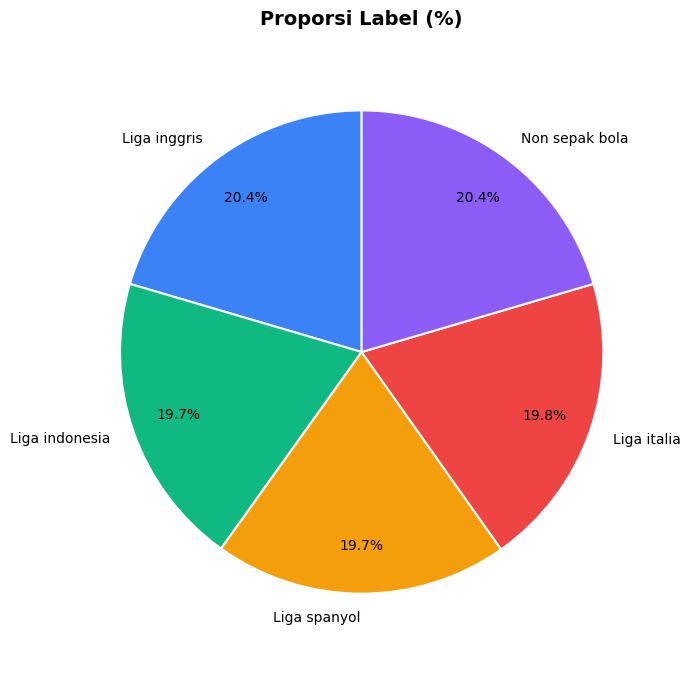

In [ ]:
import matplotlib.pyplot as plt

# Hitung jumlah tiap label
label_counts = (
    df_raw['label']
    .value_counts()
    .reindex(LABEL_ORDER, fill_value=0)
)

# Hapus label yang jumlahnya 0 (opsional)
label_counts = label_counts[label_counts > 0]

plt.figure(figsize=(7, 7))

plt.pie(
    label_counts.values,
    labels=label_counts.index,
    colors=[LABEL_COLORS[l] for l in label_counts.index],
    autopct='%1.1f%%',
    startangle=90,
    pctdistance=0.8,
    wedgeprops={
        'edgecolor': 'white',
        'linewidth': 1.5
    }
)

plt.title('Proporsi Label (%)', fontsize=14, fontweight='bold')
plt.axis('equal')   # supaya pie berbentuk lingkaran
plt.tight_layout()
plt.show()

Temuan 1 : Proporsi setiap label sudah cukup balance, bisa dilanjutkan ke proses selanjutnya

In [ ]:
df_raw.head(10)

,teks,media,label
0,"Pemain Arsenal, Declan Rice , dinilai pantas m...",Detik.com,Liga inggris
1,Legenda Manchester United Roy Keane sempat ter...,Detik.com,Liga inggris
2,Manajer Coventry City Frank Lampard terpilih m...,Detik.com,Liga inggris
3,Manchester United punya target untuk jadi juar...,Detik.com,Liga inggris
4,"Semasa melatih Liverpool , Arne Slot dikenal k...",Detik.com,Liga inggris
5,"Pemilik West Ham United , David Sullivan, terl...",Detik.com,Liga inggris
6,Chelsea dan Manchester City kabarnya terlibat ...,Detik.com,Liga inggris
7,Pep Guardiola menghabiskan 10 tahun melatih Ma...,Detik.com,Liga inggris
8,Ipswich Town meminati Ole Gunnar Solskjaer unt...,Detik.com,Liga inggris
9,"Dengan berakhirnya Premier League 2025-26, ber...",Detik.com,Liga inggris


Temuan 1 : Teks setiap berita cenderung sangat panjang. Ini normal pada data berita

Temuan 2 : Ditemukan Teks seperti SCROLL TO CONTINUE WITH CONTENT, [Gambas:Video 20detik], ataupun iklan diakhir berita seperti Lihat juga Video.... Ketiga ini perlu dihandle menggunakan regex

In [ ]:
df_raw['word_count']  = df_raw['teks'].str.split().str.len()
df_raw['sentence_count']  = df_raw['teks'].str.count(r'[.!?]+')

In [ ]:
desc = df_raw[['word_count','sentence_count']].describe().T

In [ ]:
print(desc.to_string())

                 count        mean         std   min    25%    50%    75%     max
word_count      1159.0  329.602243  134.422720  49.0  235.5  318.0  389.0  1785.0
sentence_count  1159.0   22.544435   14.063742   5.0   17.0   21.0   26.0   404.0


Temuan 1: Rata-rata panjang berita (329,60 kata) > median panjang berita (318 kata). Hal ini menandakan distribusi right skewed yang berarti mayoritas berita memiliki panjang ~318 kata, tetapi terdapat sedikit berita yang sangat panjang (hingga 1.785 kata)

Temuan 2: Rata-rata jumlah kalimat per berita (22,54 kalimat) > median jumlah kalimat per berita (21 kalimat). Hal ini menandakan distribusi right skewed yang berarti sebagian besar berita terdiri dari  ~21 kalimat, tetapi terdapat sedikit berita dengan jumlah kalimat yang sangat banyak (hingga 404 kalimat)

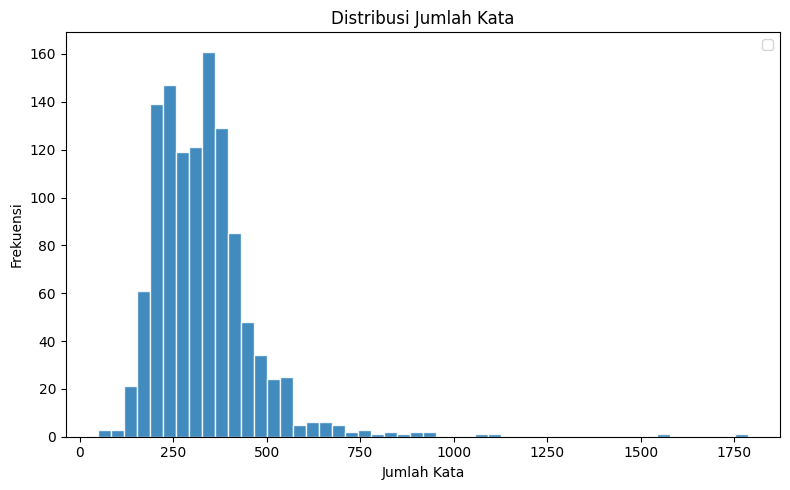

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df_raw['word_count'],
    bins=50,
    edgecolor='white',
    alpha=0.85
)

plt.title("Distribusi Jumlah Kata")
plt.xlabel("Jumlah Kata")
plt.ylabel("Frekuensi")
plt.legend()

plt.tight_layout()
plt.show()

Temuan 1: Mayoritas berita memiliki jumlah kata yang relatif sedang, yaitu sekitar 200-400 kata

Temuan 2: Terdapat sedikit outlier dengan jumlah kata > 700 kata, perlu dilakukan pengecekan pada berita tersebut untuk melihat apakah masih relevan atau tidak

In [ ]:
df_raw[df_raw['word_count'] > 700][['teks']]

,teks
118,Fenomena kerusuhan suporter kembali menjadi so...
145,"Klub asal Kota Kembang Bandung, Persib, kembal..."
503,AEF/MANTENA Cup Jakarta 2026 FEI CSI1 Internat...
518,"Petenis asal Indonesia, Janice Tjen, belakanga..."
752,SEPAK bola bukan sekadar cabang olahraga di In...
769,PIALA Dunia 2026 di Stadion Houston menjadi sa...
796,CURACAO negeri mini dengan jumlah penduduk per...
800,BUDAPEST mempunyai ikatan kuat dengan revolusi...
817,ADA pemandangan menarik usai timnas Norwegia m...
901,KOMPAS.com - Marc Cucurella resmi meninggalkan...


Ternyata berisikan berita yang masih relevan, sebaiknya jangan dihapus

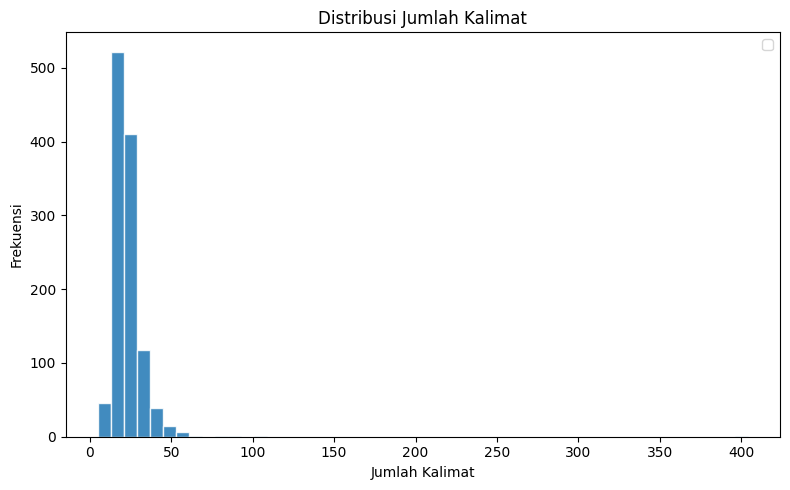

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    df_raw['sentence_count'],
    bins=50,
    edgecolor='white',
    alpha=0.85
)

plt.title("Distribusi Jumlah Kalimat")
plt.xlabel("Jumlah Kalimat")
plt.ylabel("Frekuensi")
plt.legend()

plt.tight_layout()
plt.show()

Temuan 1: Mayoritas berita memiliki jumlah kalimat yang relatif sedang, yaitu sekitar 10 - 35 kalimat

Temuan 2: Terdapat sedikit outlier dengan jumlah kalimat > 50 kalimat, bahkan mencapai sekitar 404 kalimat. Perlu dilakukan pengecekan terhadap data outlier tersebut untuk memastikan apakah masih merupakan artikel berita yang relevan atau tidak

In [ ]:
df_raw[df_raw['sentence_count'] > 50][['teks']]

,teks
118,Fenomena kerusuhan suporter kembali menjadi so...
453,Como sukses merebut tiket Liga Champions di pe...
503,AEF/MANTENA Cup Jakarta 2026 FEI CSI1 Internat...
752,SEPAK bola bukan sekadar cabang olahraga di In...
769,PIALA Dunia 2026 di Stadion Houston menjadi sa...
796,CURACAO negeri mini dengan jumlah penduduk per...
817,ADA pemandangan menarik usai timnas Norwegia m...
1069,"JAKARTA, KOMPAS.com – Sprint Race MotoGP Belan..."
1080,"JAKARTA, KOMPAS.com - Marc Marquez berhasil me..."
1091,KOMPAS.com - OSN Matematika SMP menjadi salah ...


Ternyata berita masih relevan, jadinya dipertahankan saja

In [ ]:
stopwords_id = set(stopwords.words('indonesian'))

In [ ]:
def light_clean(text):
    text = text.encode('ascii','ignore').decode('ascii')
    text = re.sub(r'[^a-zA-Z\s]',' ', text)
    text = re.sub(r'\s+',' ', text).strip().lower()
    return text

In [ ]:
df_raw['teks_clean'] = df_raw['teks'].apply(light_clean)

In [ ]:
n_cols   = 3
n_rows   = (5 + n_cols - 1) // n_cols

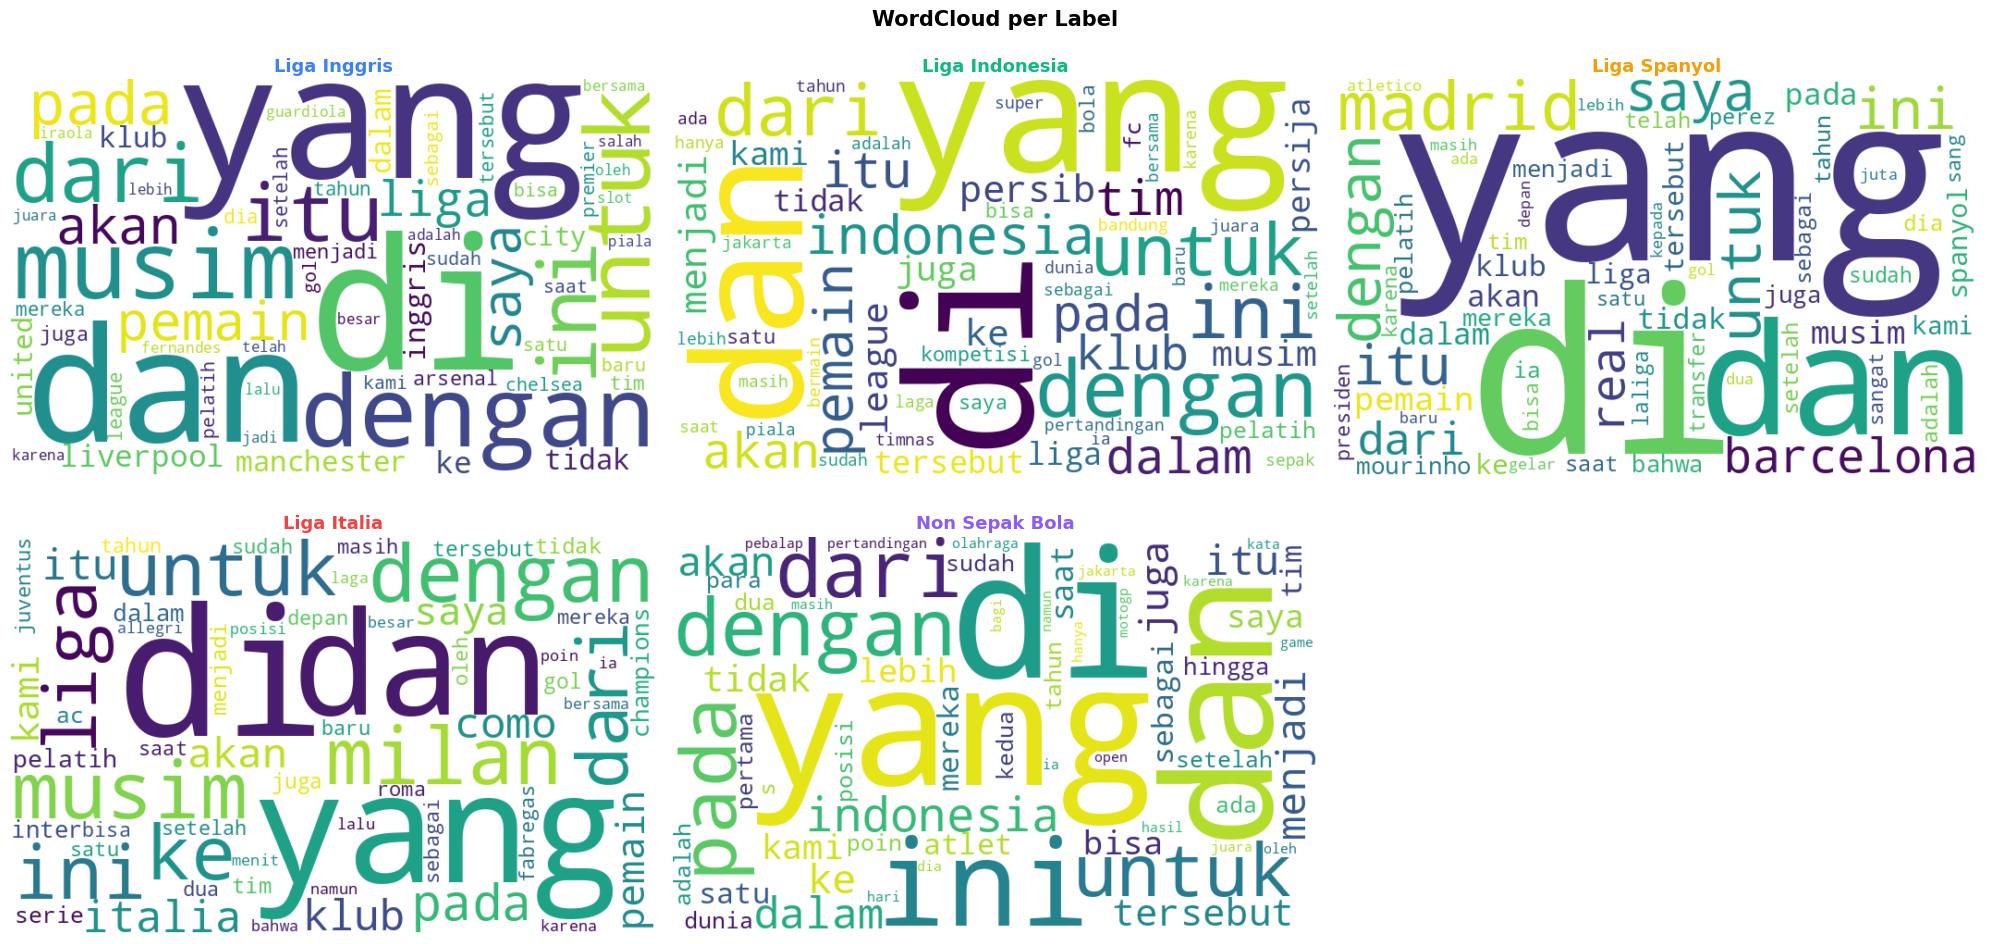

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()
fig.suptitle('WordCloud per Label', fontsize=15, fontweight='bold')

for idx, label in enumerate(LABEL_ORDER):
    texts     = ' '.join(df_raw[df_raw['label'] == label]['teks_clean'].tolist())
    hex_color = LABEL_COLORS[label].lstrip('#')
    r, g, b   = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

    wc = WordCloud(
        width=700, height=430,
        background_color='white',
        colormap='viridis',
        max_words=60,
        prefer_horizontal=0.8,
        collocations=False
    ).generate(texts)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(label.replace('_', ' ').title(), fontsize=13, fontweight='bold',
                        color=LABEL_COLORS[label])
    axes[idx].axis('off')

for j in range(5, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Temuan 1 : Setiap label memiliki kata - kata dominan yang berbeda, misalnya arsenal, manchester, dan liverpool pada Liga Inggris; persib dan indonesia pada Liga Indonesia; Kata-kata ini harus dipertahankan



Temuan 2 : Terdapat kata-kata umum seperti yang, dengan, dari, untuk, dan dalam yang masih mendominasi seluruh label sehingga kurang memberikan informasi spesifik terhadap kelas. Kata - kata ini akan ditambahkan ke custom_stopwords untuk dihapus

In [ ]:
N_TOP = 15

In [ ]:
tfidf_eda = TfidfVectorizer(max_features=8000, min_df=2, max_df=0.90, ngram_range=(1,2))
tfidf_eda.fit(df_raw["teks_clean"])
feature_names = tfidf_eda.get_feature_names_out()

In [ ]:
top_keywords = {}

for label in LABEL_ORDER:

    texts = df_raw.loc[
        df_raw["label"] == label,
        "teks_clean"
    ]

    X = tfidf_eda.transform(texts)

    mean_scores = X.mean(axis=0).A1

    top_idx = mean_scores.argsort()[::-1][:N_TOP]

    top_keywords[label] = [
        (feature_names[i], mean_scores[i])
        for i in top_idx
        if mean_scores[i] > 0
    ]

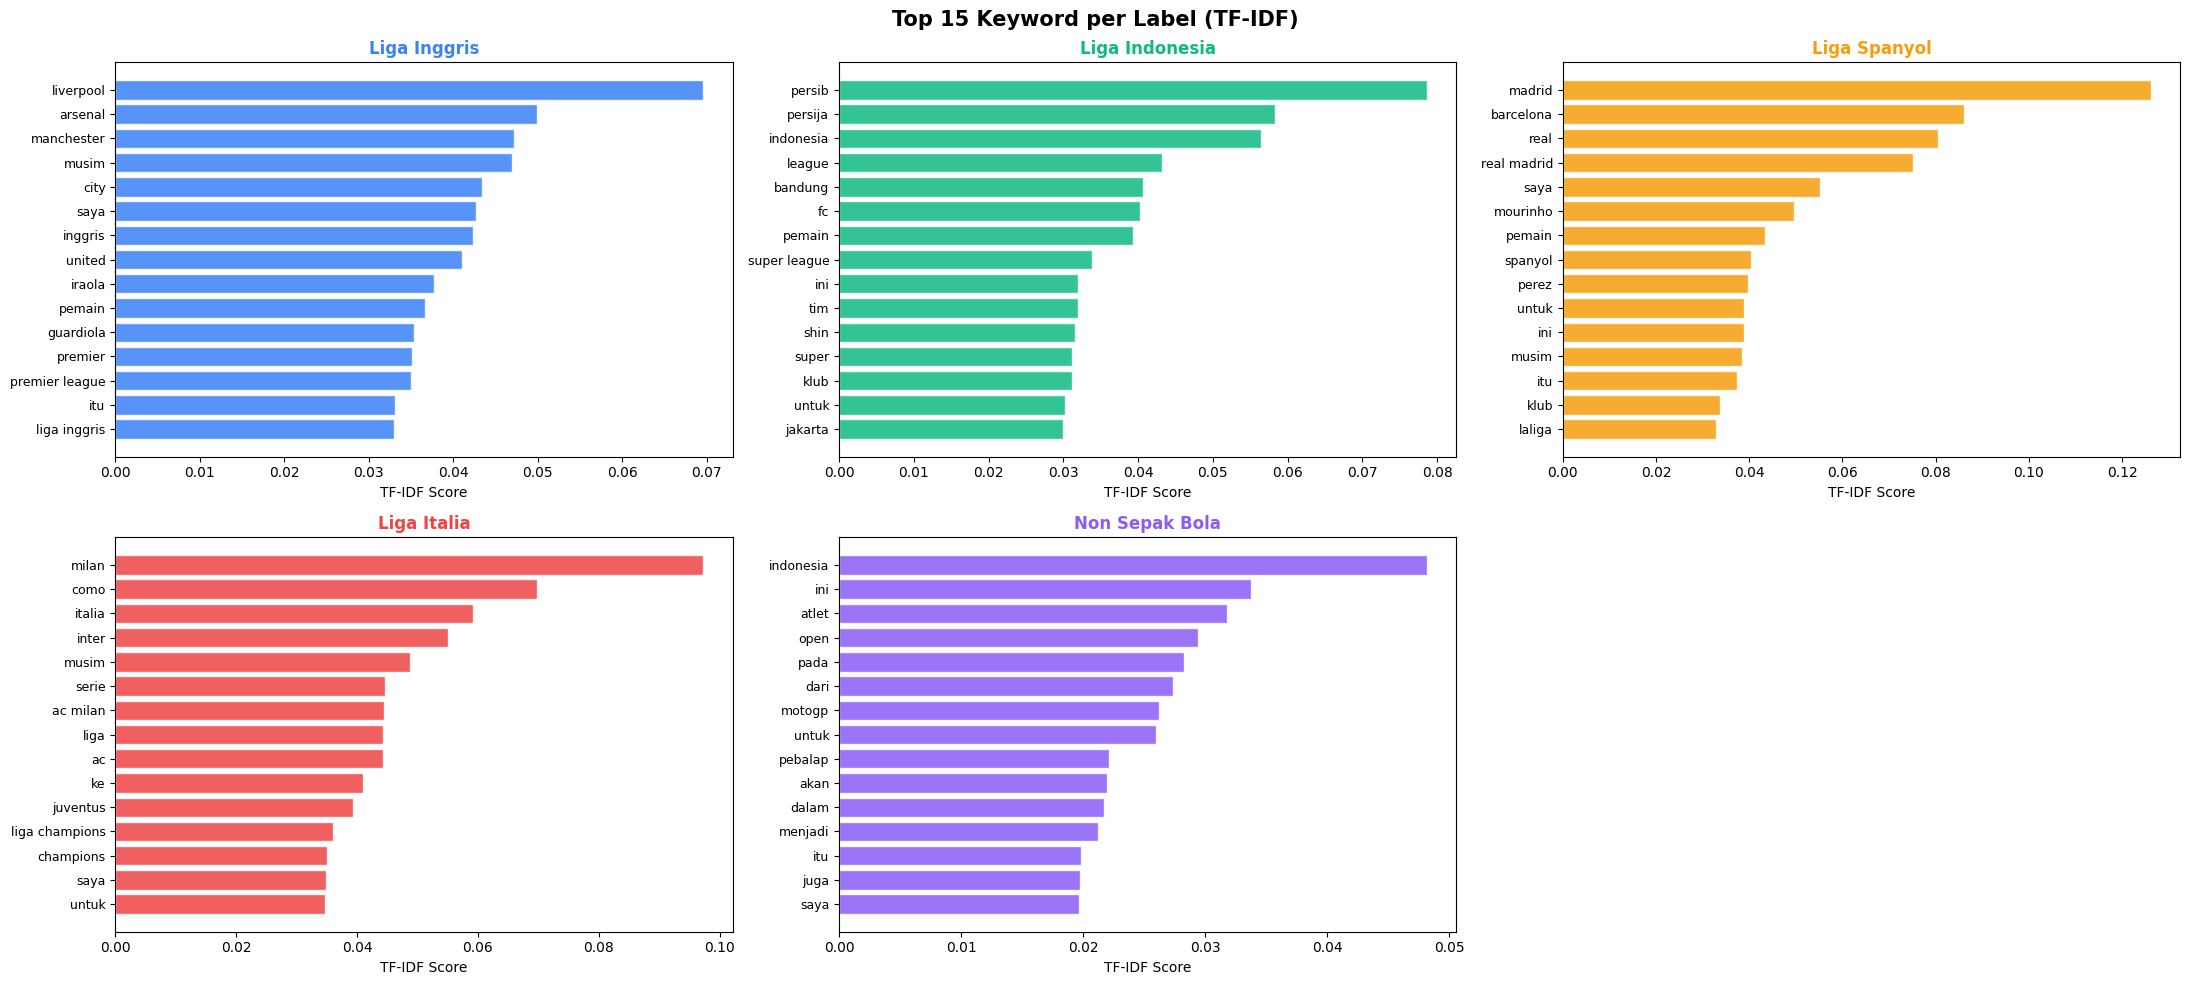

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, n_rows * 5))
axes = axes.flatten()
fig.suptitle(f'Top 15 Keyword per Label (TF-IDF)', fontsize=15, fontweight='bold')

for idx, label in enumerate(LABEL_ORDER):
    words  = [kw for kw, _ in top_keywords[label]]
    scores = [sc for _, sc in top_keywords[label]]
    color  = LABEL_COLORS[label]

    axes[idx].barh(words[::-1], scores[::-1], color=color, alpha=0.85, edgecolor='white')
    axes[idx].set_title(label.title(), fontsize=12, fontweight='bold', color=color)
    axes[idx].set_xlabel('TF-IDF Score')
    axes[idx].tick_params(axis='y', labelsize=9)

for j in range(5, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [ ]:
for label in LABEL_ORDER:
    kws = ', '.join([w for w, _ in top_keywords[label][:10]])
    print(f"  {label:<17}: {kws}")

  Liga inggris     : liverpool, arsenal, manchester, musim, city, saya, inggris, united, iraola, pemain
  Liga indonesia   : persib, persija, indonesia, league, bandung, fc, pemain, super league, ini, tim
  Liga spanyol     : madrid, barcelona, real, real madrid, saya, mourinho, pemain, spanyol, perez, untuk
  Liga italia      : milan, como, italia, inter, musim, serie, ac milan, liga, ac, ke
  Non sepak bola   : indonesia, ini, atlet, open, pada, dari, motogp, untuk, pebalap, akan


In [ ]:
vocab_per_label = {}
for label in LABEL_ORDER:
    texts = df_raw[df_raw['label'] == label]['teks_clean'].dropna().tolist()
    cv    = CountVectorizer(min_df=2)
    cv.fit(texts)
    vocab_per_label[label] = set(cv.get_feature_names_out())

In [ ]:
for label, vocab in vocab_per_label.items():
    print(f"  {label:<17}: {len(vocab):,} kata unik")

  Liga inggris     : 3,394 kata unik
  Liga indonesia   : 3,622 kata unik
  Liga spanyol     : 3,361 kata unik
  Liga italia      : 3,192 kata unik
  Non sepak bola   : 4,502 kata unik


Temuan 1 : Keragaman vocab pada non sepak bola paling banyak kemungkinan karena topik non sepak bola lebih beragam daripada domain sepak bola

In [ ]:
overlap_matrix = pd.DataFrame(0.0, index=LABEL_ORDER, columns=LABEL_ORDER)
for l1 in LABEL_ORDER:
    for l2 in LABEL_ORDER:
        if l1 == l2:
            overlap_matrix.loc[l1, l2] = 1.0
        else:
            inter = len(vocab_per_label[l1] & vocab_per_label[l2])
            union = len(vocab_per_label[l1] | vocab_per_label[l2])
            overlap_matrix.loc[l1, l2] = inter / union if union else 0

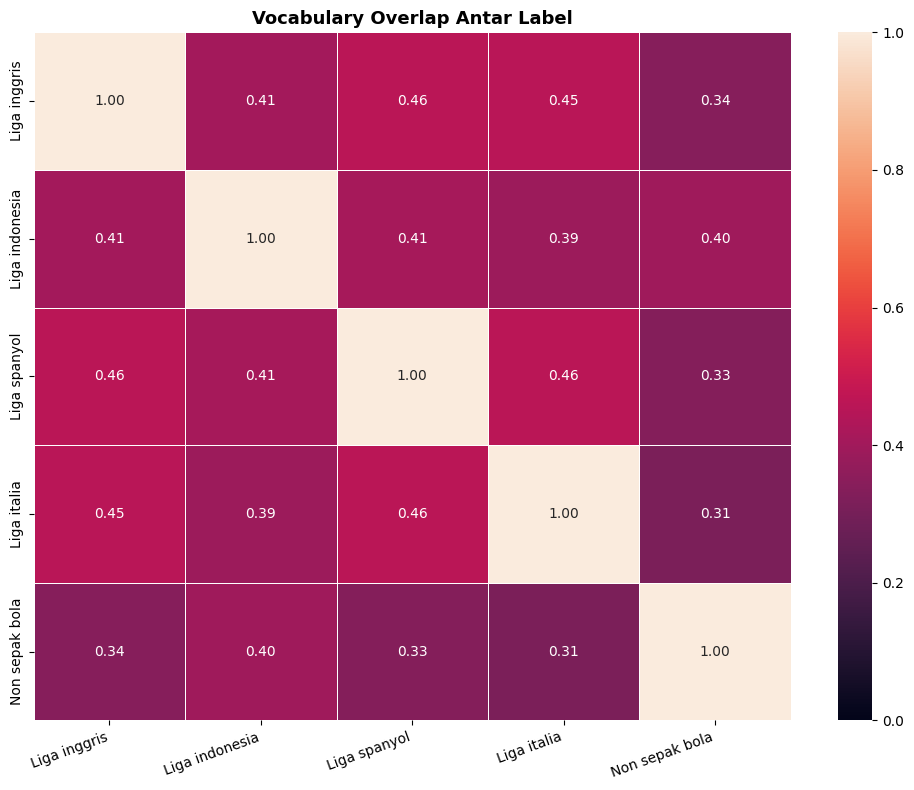

In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(overlap_matrix.astype(float), annot=True, fmt='.2f',
            xticklabels=LABEL_ORDER, yticklabels=LABEL_ORDER,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('Vocabulary Overlap Antar Label', fontsize=13, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Temuan 1 : Kemiripan kosakata antar label berada di sekitar 0,31 - 0,46 yang berarti setiap label memiliki sebagian kosakata yang sama

Temuan 2 : Kemiripan vocab tertinggi
ada pada Liga Spanyol dengan Liga Italia (0,46) dan Liga inggris (0,46) serta Liga Inggris dengan Liga Spanyol (0,46). Hal ini menunjukan bahwa kemunculan kata saja tidak dapat menyelesaikan masalah ini, tetapi juga perlu model mempelajari konteks kata, seperti menggunakan Transformer misalnya

In [ ]:
def get_unique_chars(series):
    chars = set()
    for text in series:
        chars.update(text)
    return sorted(chars)

In [ ]:
unique_chars = get_unique_chars(df_raw['teks'])

In [ ]:
unique_chars

[' ',
 '!',
 '"',
 '#',
 '%',
 '&',
 "'",
 '(',
 ')',
 '*',
 '+',
 ',',
 '-',
 '.',
 '/',
 '0',
 '1',
 '2',
 '3',
 '4',
 '5',
 '6',
 '7',
 '8',
 '9',
 ':',
 ';',
 '<',
 '=',
 '>',
 '?',
 '@',
 'A',
 'B',
 'C',
 'D',
 'E',
 'F',
 'G',
 'H',
 'I',
 'J',
 'K',
 'L',
 'M',
 'N',
 'O',
 'P',
 'Q',
 'R',
 'S',
 'T',
 'U',
 'V',
 'W',
 'X',
 'Y',
 'Z',
 '[',
 ']',
 '^',
 '_',
 'a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z',
 '{',
 '|',
 '}',
 '~',
 '\x80',
 '\x81',
 '\x82',
 '\x85',
 '\x86',
 '\x87',
 '\x89',
 '\x8b',
 '\x8c',
 '\x8d',
 '\x8e',
 '\x8f',
 '\x91',
 '\x92',
 '\x93',
 '\x94',
 '\x96',
 '\x97',
 '\x98',
 '\x99',
 '\x9a',
 '\x9b',
 '\x9c',
 '\x9d',
 '\x9f',
 '\xa0',
 '¡',
 '¢',
 '£',
 '¤',
 '¥',
 '¦',
 '§',
 '¨',
 '©',
 'ª',
 '«',
 '\xad',
 '®',
 '°',
 '±',
 '²',
 '³',
 '´',
 '¸',
 '¹',
 'º',
 '»',
 '¼',
 '½',
 '¿',
 'Á',
 'Â',
 'Ã',
 'Ä',
 'È',
 'É',
 'Ñ',
 'Ø',
 'ß',
 'à',
 

Temuan 1 : Terdapat banyak tanda baca, angka, dan simbol yang perlu dilakukan cleaning

Temuan 2 : Terdapat karakter hasil kesalahan encoding, seperti \x80, \x91, \x92, dan lainnya. Perlu adanya normalisasi encoding

Temuan 3 : Ada karakter spasi khusus \xa0 yang perlu dihandle

In [ ]:
pattern = r"http\S+|www\S+|@\w+|#\w+"

df_raw['has_special'] = df_raw['teks'].str.contains(pattern, na=False)

In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
df_raw[df_raw['has_special']]['teks']

,teks
31,"Arne Slot dituding arogan semasa menjadi pelatih Liverpool . Dia diklaim suka merendahkan para pemainnya yang berasal dari Liga Jerman . Liverpool mendepak Slot dari jabatan pelatih pada awal Juni 2026. Juru taktik asal Belanda itu dipecat setelah hasil buruk Merseyside Merah musim ini. Liverpool gagal total sepanjang musim 2025/2026 tanpa ada gelar yang diraih. Slot padahal sudah menghabiskan biaya kurang lebih 400 juta poundsterling untuk belanja pemain di awal musim. SCROLL TO CONTINUE WITH CONTENT Florian Wirtz, Jeremie Frimpong, Hugo Ekitike diboyong Slot pada musim panas 2025, Ketiganya direkrut dari klub-klub Bundesliga, dengan total pembelian mencapai 200 juta poundsterling. Laporan terbaru media Jerman Bild mengungkapkan masalah Slot di ruang ganti Liverpool. Eks pelatih Feyenoord itu dianggap bermasalah dengan cara berinteraksi dengan para bintang. Slot dituding mencampurkan kritik objektif dengan sindiran pribadi yang arogan, terutama kepada ketiga pemain barunya yang berasal dari Bundesliga. Dia kerap melontarkan pertanyaan seperti 'apakah kalian memenangkan Premier League?' atau 'begitukah cara kalian bermain di Jerman?'. Kata-kata pedas Slot itu tidak diterima dengan baik tak hanya oleh ketiga pemain baru Liverpool. Ibrahima Konate, Dominik Szoboszlai, Ryan Gravenberch, dan Wataru Endo yang notabene pernah bermain di Bundesliga juga tak senang dengan itu. Arne Slot used arrogant, personal digs against last summer's signings Florian Wirtz (Â£100m), Jeremie Frimpong (Â£30m), and Hugo Ekitike (Â£70m), asking questions like ""did you win the Premier League?"" and telling them that ""this is how you can play in Germany"" ð³ð ( @AxelHesse1 ) pic.twitter.com/Q53Wj6bdES Arne Slot juga gagal meneruskan tradisi permainan pressing Liverpool yang dibawa pendahulunya Juergen Klopp. Hal itu sempat disuarakan Mohamed Salah yang menyerukan kembalinya sepakbola ala 'heavy metal' ke Anfield. Liverpool kini sudah mendapatkan pelatih baru pengganti Arne Slot. Eks manajer Bournemouth Andoni Iraola yang ditunjuk sebagai juru taktik anyar Merseyside Merah."
41,"Pep Guardiola lagi viral gara-gara bicara dengan sosok tak berwujud di sebuah pertandingan. Tapi, sebenarnya ada kok yang diajak ngobrol Pep. Siapa? Dalam acara seremoni perpisahan Pep setelah 10 tahun menangani Manchester City , setiap pemain diberikan kesempatan untuk memberikan pertanyaan yang tidak biasa-biasa saja. Bernardo Silva melemparkan pertanyaan yang sangat menarik. Dia bertanya kepada Pep soal sosok tak berwujud yang diajak bicara dalam kekalahan Man City dari Arsenal di semifinal Piala FA 2019/2020. SCROLL TO CONTINUE WITH CONTENT ""Semua orang ingin tahu, saat ini, dengan siapa kamu berbicara?"" kata Bernardo Silva yang membuat Pep tertawa malu saat cuplikan video disajikan di hadapan publik. Saat Pep ditodong mikrofon oleh host, dia menolak menjawab pertanyaan Bernardo Silva. Sontak netizen pun berspekulasi bahwa Pep kala itu merindukan Mikel Arteta yang direkrut Arsenal di pertengahan musim 2019/2020. Arteta kala itu berstatus sebagai asisten Pep. Namun, terkuak sudah siapa sebenarnya yang diajak bicara oleh Pep, yakni dua asistennya yang duduk berjarak darinya. Mereka adalah Juanma Lilo dan Rodolfo Borrell, yang sudah meninggalkan klub lebih dulu ketimbang Pep. ""Kami punya jawabannya #EmiratesFACup,"" ujar akun X @EmiratesFACup menjawab pertanyaan akun @Priceless_MCI. z [Gambas:Twitter]"
110,"Andoni Iraola semakin dekat menjadi manajer baru Liverpool . Pembicaraan lanjutan di antara dua pihak sedang dilakukan. Liverpool sedang mencari manajer baru usai mendepak Arne Slot akhir pekan lalu. Salah satu nama yang diunggulkan mengisi posisi itu ialah Iraola. Kontrak Iraola bersama Bournemouth memang sudah berakhir pada musim panas 2026. Pelatih berusia 43 tahun itu memutuskan cabut usai membawa The Cherries lolos ke Liga Europa untuk pertama kalinya. SCROLL TO CONTINUE WITH CONTENT Melansir Sky Sports , Liverpool sudah mengadakan pembicaraan dengan I

Temuan 1 : Ada beberapa teks mengandung tags,mention, dan link. Perlu di handle waktu cleaning

In [ ]:
all_keywords = []

for label in LABEL_ORDER:
    words = [kw for kw, _ in top_keywords[label]]
    all_keywords.extend(words)

In [ ]:
keyword_counter = Counter(all_keywords)

candidate_stopwords = pd.DataFrame({
    "word": keyword_counter.keys(),
    "n_label": keyword_counter.values()
})

candidate_stopwords = (
    candidate_stopwords
    .sort_values(
        by=["n_label", "word"],
        ascending=[False, True]
    )
    .reset_index(drop=True)
)


In [ ]:
candidate_stopwords[candidate_stopwords["n_label"] >= 3]

,word,n_label
0,saya,4
1,untuk,4
2,ini,3
3,itu,3
4,musim,3
5,pemain,3


Temuan 1: Terdapat kata kata domain stopwords yang sebaiknya dihandle seperti "saya" , "untuk" , "ini" , dan "itu" tidak mememberikan makna semantik. Sebaiknya di handle

# Text Preprocessing

Disini kita pakai stopwords removal/domainword removal karena wajib dari soal. Lalu, tidak dilakukan stemming/lematisasi karena :
1. Bert dipretrained dalam dataset yang kotor yang tidak melalui stemming/lematisasi. Jika menambahkan lematisasi/stemming maka kurang berguna. Lalu Bert itu memakai subword tokenizing jadi walaupun tidak pakai lematisasi dia masih tetep bisa misahin kata-kata imbuhan tanpa kehilangan konteks makna tanpa harus kita manually hilangin imbuhan


In [ ]:
stanza.download('id', verbose=False)

models/default.zip:   0%|          | 0.00/394M [00:00<?, ?B/s]

[['zip', 'default.zip']]

In [ ]:
stop_words_id = set(stopwords.words('indonesian'))

In [ ]:
KEEP_WORDS = {
    "tidak",
    "tak",
    "bukan",
    "belum"
}

stop_words_id = stop_words_id - KEEP_WORDS

In [ ]:
CUSTOM_STOPWORDS = {
    "ini",
    "itu",
    "untuk",
    "dari",
    "pada",
    "akan",
    "ke",
    "dan",
    "yang",
    "dengan"
}

In [ ]:
DOMAIN_STOPWORDS = {
    "saya",
    "untuk",
    "ini",
    "itu"
}

In [ ]:
stop_words = (
    stop_words_id
    | DOMAIN_STOPWORDS
    | CUSTOM_STOPWORDS
)

In [ ]:
patterns = [
        r'scroll\s+to\s+continue\s+with\s+content',
        r'lihat\s+juga.*?(?=\n|$)',
        r'\[gambas:video.*?\]',
        r'gambas\s*:?\s*video\s*\d*\s*detik',
    ]

In [ ]:
def clean_raw(text):
    text = text.encode("ascii", "ignore").decode("ascii")

    text = text.lower()

    text = text.replace("\xa0", " ")

    text = re.sub(
        r'http\S+|www\.\S+|@\w+|#\w+',
        ' ',
        text
    )

    for p in patterns:
        text = re.sub(p, ' ', text, flags=re.IGNORECASE)

    text = re.sub(r'[^a-zA-Z\s]', ' ', text)

    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [ ]:
def preprocess_text_bert(text):

    text = clean_raw(text)

    if not text:
      return ""

    tokens = text.split()

    tokens = [
        token
        for token in tokens
        if token not in stop_words and len(token) >= 2
    ]

    return " ".join(tokens)

In [ ]:
df_raw["text_clean"] = (
    df_raw["teks"]
    .progress_apply(preprocess_text_bert)
)

  0%|          | 0/1159 [00:00<?, ?it/s]

In [ ]:
df_raw[df_raw['text_clean'].str.split().str.len() < 3]

,teks,media,label,word_count,sentence_count,teks_clean,has_special,text_clean


In [ ]:
sample = df_raw[['teks', 'text_clean']].head(5)
for _, row in sample.iterrows():
    print(f'  RAW   : {row["teks"]}')
    print(f'  CLEAN : {row["text_clean"]}')
    print()

  RAW   : Pemain Arsenal, Declan Rice , dinilai pantas menjadi peraih penghargaan pemain terbaik Premier League musim ini. Dia mengantarkan The Gunners juara. Pemain Manchester United, Bruno Fernandes, menyabet anugerah pemain terbaik Liga Inggris musim ini. Performanya memang maksimal untuk The Red Devils musim ini, tapi hanya finis ketiga. Bruno Fernandes juga menyamai rekor assist di Premier League atas nama Thierry Henry dan Kevin De Bruyne. Mereka membukukan total 20 assist di sepanjang musim 2025/2026. SCROLL TO CONTINUE WITH CONTENT  Jurnalis Inggris, Piers Morgan, tak setuju dengan penghargaan untuk pemain asal Portugal itu. Rice dinilai lebih pantas untuk menerima piala itu karena mampu membawa Arsenal juara. "Konyol... Seharusnya yang menang Declan Rice. Lawak banget orang yang timnya nggak pernah sekalipun bersaing buat gelar juara malah menang atas pemain yang kehebatannya sepanjang musim membawa kami jadi juara," kata Morgan seperti dikabarkan oleh Sportskeeda. Arsenal jug

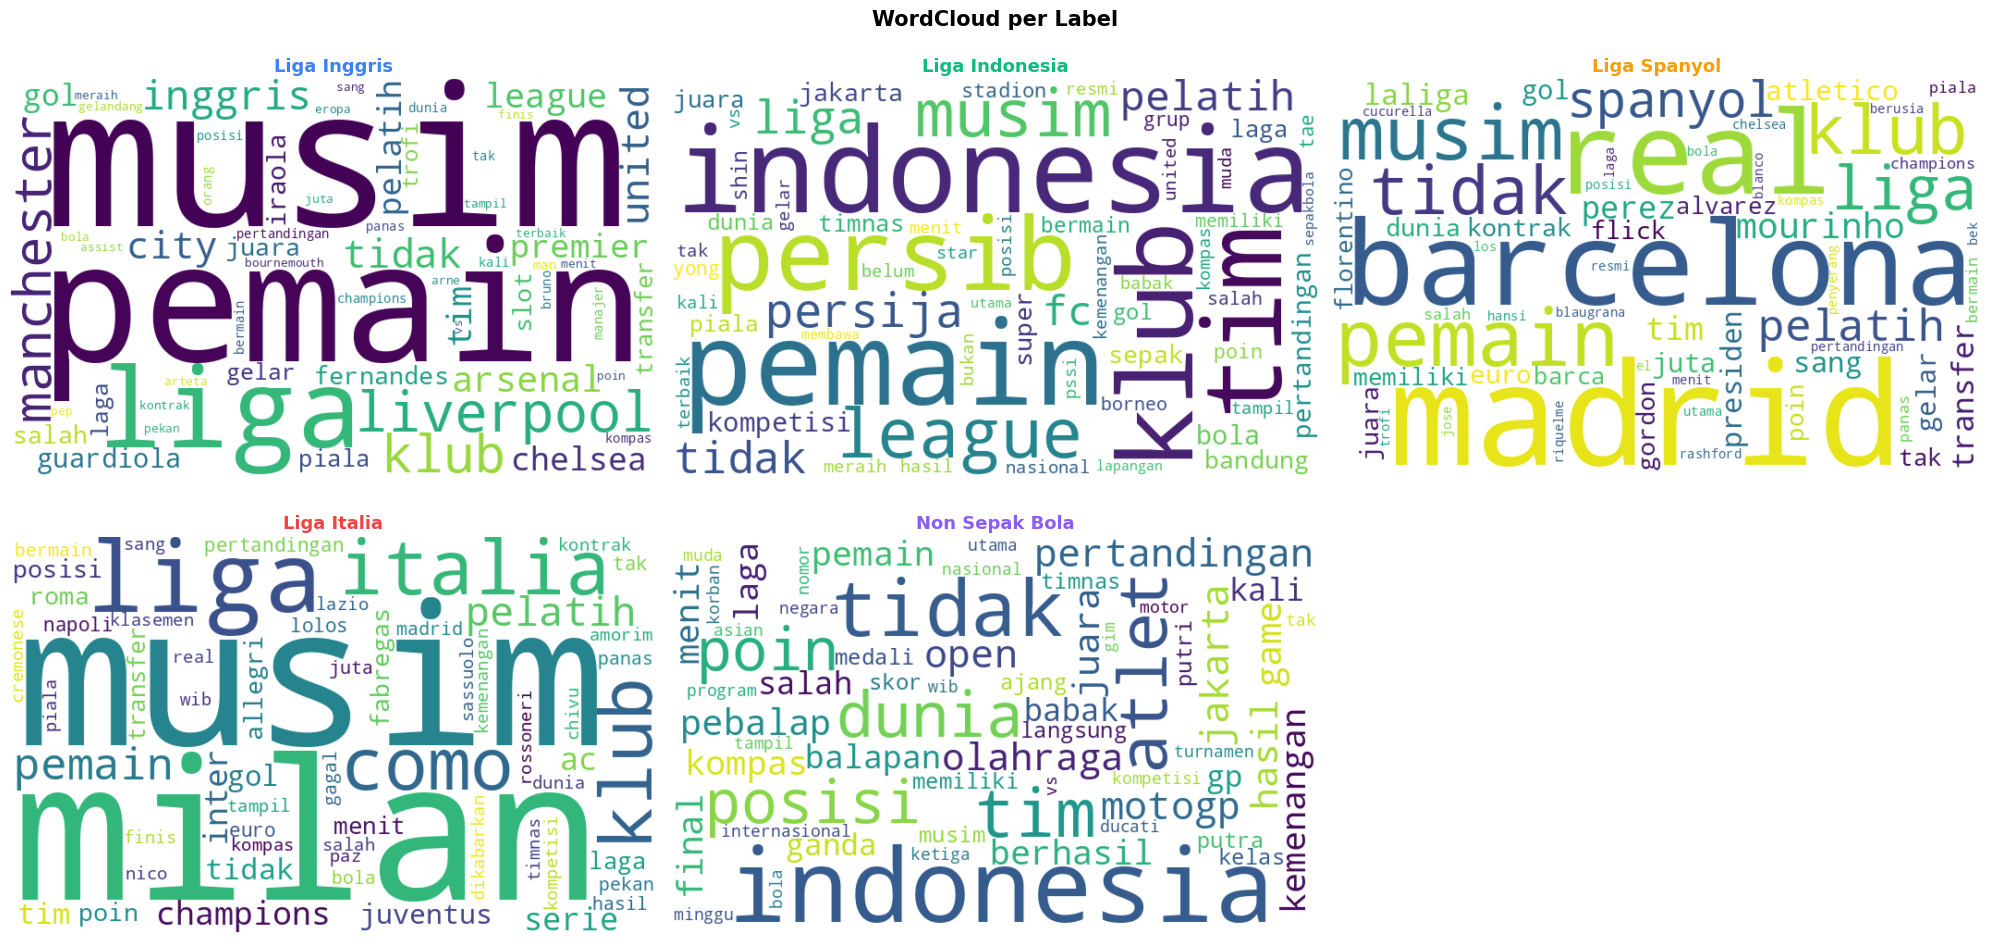

In [ ]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()
fig.suptitle('WordCloud per Label', fontsize=15, fontweight='bold')

for idx, label in enumerate(LABEL_ORDER):
    texts     = ' '.join(df_raw[df_raw['label'] == label]['text_clean'].dropna().tolist())
    hex_color = LABEL_COLORS[label].lstrip('#')
    r, g, b   = tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

    wc = WordCloud(
        width=700, height=430,
        background_color='white',
        colormap='viridis',
        max_words=60,
        prefer_horizontal=0.8,
        collocations=False
    ).generate(texts)

    axes[idx].imshow(wc, interpolation='bilinear')
    axes[idx].set_title(label.replace('_', ' ').title(), fontsize=13, fontweight='bold',
                        color=LABEL_COLORS[label])
    axes[idx].axis('off')

for j in range(5, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Train Test Split

Disini akan digunakan indolem/indobert-base-uncase uncased. Model ini dipilih karena sudah di latih pada dokumen dengan teks bahasa indonesia pada jumlah besar sehingga cocok untuk teks berita yang besar dan panjang

In [ ]:
PRETRAINED_MODEL = 'indolem/indobert-base-uncased'

label model 1

In [ ]:
LABEL2ID_5 = {
    'Non sepak bola': 0,
    'Liga italia': 1,
    'Liga indonesia': 2,
    'Liga spanyol': 3,
    'Liga inggris': 4
}
ID2LABEL_5 = {v: k for k, v in LABEL2ID_5.items()}

Label Model 2

In [ ]:
LABEL2ID_BINER = {
    'Non sepak bola': 0,
    'Sepak bola': 1
}
ID2LABEL_BINER = {v: k for k, v in LABEL2ID_BINER.items()}

In [ ]:
LABEL2ID_LIGA = {
    'Liga inggris': 0,
    'Liga indonesia': 1,
    'Liga spanyol': 2,
    'Liga italia': 3
}
ID2LABEL_LIGA = {v: k for k, v in LABEL2ID_LIGA.items()}

Splitting data

In [ ]:
df_model = df_raw[['text_clean', 'label']].copy()

In [ ]:
df_model['label_id_5'] = df_model['label'].map(LABEL2ID_5)

In [ ]:
df_model['label_biner'] = df_model['label'].apply(
    lambda x: 0 if x == 'Non sepak bola' else 1
)
df_model['label_id_liga'] = df_model['label'].map(LABEL2ID_LIGA)

In [ ]:
train_df, temp_df = train_test_split(df_model, test_size=0.30, stratify=df_model['label_id_5'], random_state=42)
val_df, test_df   = train_test_split(temp_df,  test_size=0.50, stratify=temp_df['label_id_5'],  random_state=42)

In [ ]:
print(f"Train: {len(train_df)}")
print(f"Val: {len(val_df)}")
print(f"Test: {len(test_df)}")

Train: 811
Val: 174
Test: 174


In [ ]:
train_df['label'].value_counts()

,count
label,
Non sepak bola,166
Liga inggris,166
Liga italia,160
Liga indonesia,160
Liga spanyol,159


In [ ]:
train_df['label_biner'].value_counts()

,count
label_biner,
1,645
0,166


In [ ]:
def make_hf_dataset(df_split, text_col, label_col, tokenizer, max_length=256):
    dataset = Dataset.from_dict({
        'text':  df_split[text_col].tolist(),
        'label': df_split[label_col].tolist()
    })
    def tokenize_fn(batch):
        return tokenizer(
            batch['text'],
            truncation=True,
            padding='max_length',
            max_length=max_length
        )
    dataset = dataset.map(tokenize_fn, batched=True)

    return dataset


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy':  accuracy_score(labels, preds),
        'precision': precision_score(labels, preds, average='weighted', zero_division=0),
        'recall':    recall_score(labels, preds, average='weighted', zero_division=0),
        'f1':        f1_score(labels, preds, average='weighted', zero_division=0),
    }


def evaluate_split(trainer, dataset, split_name=''):
    results = trainer.evaluate(dataset)
    print(f"{split_name}")
    for k, v in results.items():
        if any(m in k for m in ['accuracy', 'precision', 'recall', 'f1']):
            print(f"  {k}: {v:.4f}")
    return results

# Model 1 (LLM 1 Stage)

## Text Representation

In [ ]:
tokenizer_1stage = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)

In [ ]:
tokenizer_1stage = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)

model_1stage = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL,
    num_labels=5,
    id2label=ID2LABEL_5,
    label2id=LABEL2ID_5
)

[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `2`.


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
model_1stage.num_parameters()

110562053

In [ ]:
token_lengths = train_df["text_clean"].apply(
    lambda x: len(tokenizer_1stage.encode(x, add_special_tokens=True))
)

token_lengths.describe()

,text_clean
count,811.000000
mean,229.080148
std,99.771107
min,51.000000
25%,159.000000
50%,217.000000
75%,269.000000
max,1083.000000


Disini dipilih 256 karena sudah mencakup sebagian besar dokumen tanpa truncation yang signifikan. Disini tidak dipilih 512 karena trade-off antara waktu pelatihan dan cakupan informasi kurang baik

In [ ]:
MAX_LEN = 256

In [ ]:
ds_train_1s = make_hf_dataset(train_df, 'text_clean', 'label_id_5', tokenizer_1stage, MAX_LEN)
ds_val_1s   = make_hf_dataset(val_df,   'text_clean', 'label_id_5', tokenizer_1stage, MAX_LEN)
ds_test_1s  = make_hf_dataset(test_df,  'text_clean', 'label_id_5', tokenizer_1stage, MAX_LEN)

Map:   0%|          | 0/811 [00:00<?, ? examples/s]

Map:   0%|          | 0/174 [00:00<?, ? examples/s]

Map:   0%|          | 0/174 [00:00<?, ? examples/s]

Train: 811 | Val: 174 | Test: 174


In [ ]:
print(f"Train: {len(ds_train_1s)}")
print(f"Val: {len(ds_val_1s)}")
print(f"Test: {len(ds_test_1s)}")

In [ ]:
data_collator = DataCollatorWithPadding(tokenizer=tokenizer_1stage)

## Hyperparameter Tuning

In [ ]:
results_m1 = []

In [ ]:
learning_rates = [1e-5, 2e-5, 3e-5]
batch_sizes = [8, 16, 32]

In [ ]:
best_f1 = 0
best_params = None

In [ ]:
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"Current Parameters:")
        print(f"Learning Rate : {lr}")
        print(f"Batch Size    : {bs}")
        training_args = TrainingArguments(
            learning_rate=lr,
            per_device_train_batch_size=bs,
            per_device_eval_batch_size=bs,
            num_train_epochs=2,
            weight_decay=0.01,
            warmup_ratio=0.1,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1',
            report_to='none'
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            PRETRAINED_MODEL,
            num_labels=5,
            id2label=ID2LABEL_5,
            label2id=LABEL2ID_5
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=ds_train_1s,
            eval_dataset=ds_val_1s,
            compute_metrics=compute_metrics,
            data_collator=data_collator
        )

        trainer.train()

        result = trainer.evaluate()

        results_m1.append({
            "Learning Rate": lr,
            "Batch Size": bs,
            "Accuracy": result["eval_accuracy"],
            "Precision": result["eval_precision"],
            "Recall": result["eval_recall"],
            "Weighted F1": result["eval_f1"]
        })


        if result["eval_f1"] > best_f1:
            best_f1 = result["eval_f1"]
            best_params = (lr, bs)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Current Parameters:
Learning Rate : 1e-05
Batch Size    : 8


[transformers] You passed `num_labels=5` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.676127,0.885057,0.891094,0.885057,0.884342
2,No log,0.354235,0.931034,0.931867,0.931034,0.929851


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.354235,2,0.931034,0.931867,0.931034,0.929851


In [ ]:
results_df_m1 = pd.DataFrame(results_m1)

results_df_m1 = results_df_m1.sort_values(
    by="Weighted F1",
    ascending=False
)

In [ ]:
results_df_m1

,Learning Rate,Batch Size,Accuracy,Precision,Recall,Weighted F1
3,0.00002,8,0.936782,0.936904,0.936782,0.936095
6,0.00003,8,0.931034,0.932752,0.931034,0.930787
5,0.00002,32,0.931034,0.932589,0.931034,0.930577
7,0.00003,16,0.931034,0.931566,0.931034,0.930049
8,0.00003,32,0.931034,0.931867,0.931034,0.929851
4,0.00002,16,0.919540,0.922875,0.919540,0.919056
0,0.00001,8,0.908046,0.907594,0.908046,0.905697
1,0.00001,16,0.902299,0.907078,0.902299,0.901999
2,0.00001,32,0.821839,0.835042,0.821839,0.816930


In [ ]:
print(best_params)
print(best_f1)

(2e-05, 8)
0.9360947380191185


## Training Model

In [ ]:
LEARNING_RATE  = 2e-5
BATCH_SIZE     = 8

In [ ]:
WEIGHT_DECAY   = 0.01
WARMUP_RATIO   = 0.1

In [ ]:
training_args_1s = TrainingArguments(
    output_dir='./results_1stage',
    num_train_epochs=20,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_ratio=WARMUP_RATIO,
    eval_strategy ='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_dir='./logs_1stage',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=42
)

trainer_1s = Trainer(
    model=model_1stage,
    args=training_args_1s,
    train_dataset=ds_train_1s,
    eval_dataset=ds_val_1s,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
trainer_1s.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,1.292143,0.852136,0.867816,0.891791,0.867816,0.865921
2,0.258351,0.293465,0.919540,0.921480,0.919540,0.919151
3,0.230761,0.316781,0.913793,0.918818,0.913793,0.913781
4,0.177573,0.311593,0.931034,0.934127,0.931034,0.930550
5,0.095320,0.389863,0.936782,0.938478,0.936782,0.935478
6,0.038419,0.347671,0.948276,0.949997,0.948276,0.947346
7,0.016073,0.384636,0.936782,0.937192,0.936782,0.936318
8,0.037040,0.397931,0.936782,0.937791,0.936782,0.936303
9,0.011789,0.396287,0.942529,0.942427,0.942529,0.942102
10,0.006396,0.416174,0.942529,0.943154,0.942529,0.941971


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=1122, training_loss=0.217547414801125, metrics={'train_runtime': 731.8741, 'train_samples_per_second': 22.162, 'train_steps_per_second': 2.787, 'total_flos': 1173638474460672.0, 'train_loss': 0.217547414801125, 'epoch': 11.0})

## Evaluation Model 1

In [ ]:
log_history = pd.DataFrame(trainer_1s.state.log_history)
log_history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.583098,13.476941,0.000005,0.490196,50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.292143,15.178700,0.000010,0.980392,100,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,102,0.852136,0.867816,0.891791,0.867816,0.865921,0.7691,226.238,28.605,NaN,NaN,NaN,NaN,NaN
3,0.592058,36.334492,0.000015,1.470588,150,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0.258351,1.375504,0.000020,1.960784,200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
train_logs = log_history[log_history["loss"].notna()][["epoch", "loss"]]
eval_logs = log_history[log_history["eval_loss"].notna()][["epoch", "eval_loss"]]

In [ ]:
print(eval_logs)

    epoch  eval_loss
2     1.0   0.852136
5     2.0   0.293465
8     3.0   0.316781
11    4.0   0.311593
14    5.0   0.389863
17    6.0   0.347671
20    7.0   0.384636
23    8.0   0.397931
26    9.0   0.396287
29   10.0   0.416174
32   11.0   0.383911
34   11.0   0.019234
35   11.0   0.347671
36   11.0   0.202915


In [ ]:
eval_logs = (
    log_history[log_history["eval_loss"].notna()]
    .groupby("epoch", as_index=False)
    .first()
)

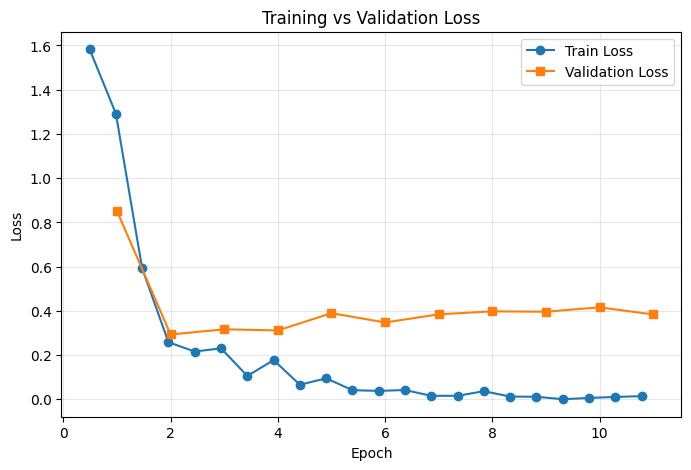

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_logs["epoch"], train_logs["loss"],
         marker='o', label='Train Loss')

plt.plot(eval_logs["epoch"], eval_logs["eval_loss"],
         marker='s', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [ ]:
res_train_1s = evaluate_split(trainer_1s, ds_train_1s, '1-Stage TRAIN')
res_val_1s   = evaluate_split(trainer_1s, ds_val_1s,   '1-Stage VALIDATION')
res_test_1s  = evaluate_split(trainer_1s, ds_test_1s,  '1-Stage TEST')

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.014631,0.019234,11,0.993835,0.993880,0.993835,0.993816


1-Stage TRAIN
  eval_accuracy: 0.9938
  eval_precision: 0.9939
  eval_recall: 0.9938
  eval_f1: 0.9938


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.014631,0.347671,11,0.948276,0.949997,0.948276,0.947346


1-Stage VALIDATION
  eval_accuracy: 0.9483
  eval_precision: 0.9500
  eval_recall: 0.9483
  eval_f1: 0.9473


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.014631,0.202915,11,0.971264,0.972067,0.971264,0.971084


1-Stage TEST
  eval_accuracy: 0.9713
  eval_precision: 0.9721
  eval_recall: 0.9713
  eval_f1: 0.9711


In [ ]:
preds_1s = trainer_1s.predict(ds_test_1s)
y_pred_1s = np.argmax(preds_1s.predictions, axis=-1)
y_true_1s = test_df['label_id_5'].tolist()

In [ ]:
print(classification_report(y_true_1s, y_pred_1s, target_names=list(LABEL2ID_5.keys())))

                precision    recall  f1-score   support

Non sepak bola       0.97      0.97      0.97        36
   Liga italia       0.97      1.00      0.99        34
Liga indonesia       0.94      1.00      0.97        34
  Liga spanyol       0.97      0.97      0.97        35
  Liga inggris       1.00      0.91      0.96        35

      accuracy                           0.97       174
     macro avg       0.97      0.97      0.97       174
  weighted avg       0.97      0.97      0.97       174



- Non sepak bola memperoleh nilai precision, recall, dan F1-score sebesar 0,97, yang menunjukkan model mampu mengklasifikasikan berita non sepak bola secara akurat dan konsisten. Nilai precision dan recall yang seimbang mengindikasikan bahwa kesalahan prediksi pada kelas ini relatif rendah

- Liga Italia memperoleh F1-score tertinggi sebesar 0,99 dengan recall 1,00, yang berarti seluruh data Liga Italia berhasil dikenali oleh model. Nilai precision sebesar 0,97 menunjukkan masih terdapat sedikit data dari kelas lain yang diprediksi sebagai Liga Italia

- Liga Indonesia memiliki recall sebesar 1,00, sehingga seluruh berita Liga Indonesia berhasil terdeteksi oleh model. Namun, nilai precision sebesar 0,94 menunjukkan masih terdapat beberapa berita dari kelas lain yang salah diklasifikasikan sebagai Liga Indonesia

- Liga Spanyol memperoleh nilai precision, recall, dan F1-score sebesar 0,97, yang menunjukkan performa klasifikasi yang stabil. Keseimbangan antara precision dan recall menunjukkan model mampu mengenali kelas ini dengan tingkat kesalahan yang rendah

- Liga Inggris memiliki precision sebesar 1,00, yang berarti seluruh prediksi Liga Inggris yang dihasilkan model adalah benar. Akan tetapi, nilai recall sebesar 0,91 menunjukkan masih terdapat sebagian berita Liga Inggris yang salah diprediksi ke kelas lain.

- Accuracy model mencapai 0,97, yang menunjukkan bahwa 97% dari total 174 data uji berhasil diklasifikasikan dengan benar. Nilai ini artinya model BERT memiliki tingkat akurasi yang sangat tinggi dalam melakukan klasifikasi berita

- Macro Average memperoleh nilai precision, recall, dan F1-score sebesar 0,97, yang menunjukkan performa model relatif merata pada seluruh kelas. Hal ini mengindikasikan bahwa tidak terdapat perbedaan performa yang signifikan antar kelas

- Weighted Average juga memperoleh nilai 0,97 untuk precision, recall, dan F1-score. Kesamaan nilai weighted average dengan macro average menunjukkan bahwa distribusi jumlah data pada setiap kelas relatif seimbang sehingga tidak ada kelas yang mendominasi hasil evaluasi

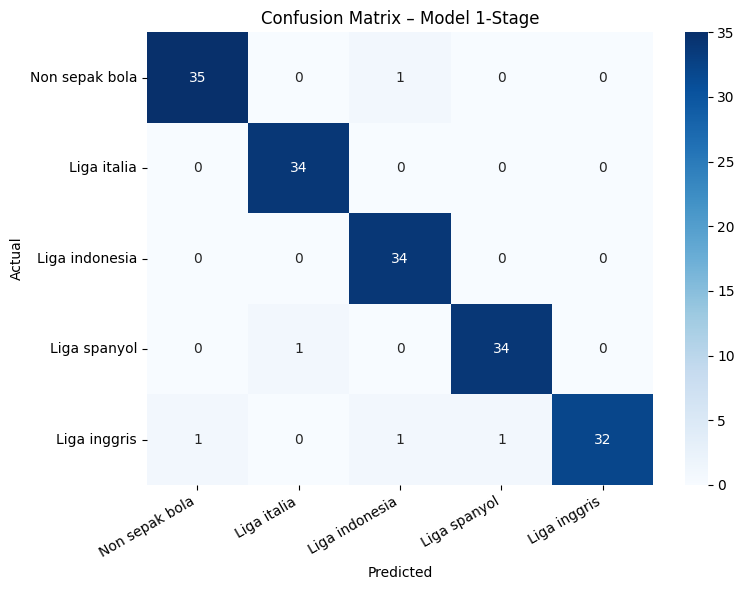

In [ ]:
cm_1s = confusion_matrix(y_true_1s, y_pred_1s)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_1s, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL2ID_5.keys(), yticklabels=LABEL2ID_5.keys())
plt.title('Confusion Matrix – Model 1-Stage')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('cm_1stage.png', dpi=150)
plt.show()

# Model 2 (LLM 2 Stage)

## Text Representation

Stage 1

In [ ]:
tokenizer_s1 = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
model_stage1 = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL,
    num_labels=2,
    id2label=ID2LABEL_BINER,
    label2id=LABEL2ID_BINER
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Pada stage 1, max len dipih 128 karena hanya perlu membedakan sepak bola dan non sepak bola dimana model tidak perlu memahami seluruh dokumen untuk membedakan antara kedua itu. Walaupun max_len 128 tidak mencakup seluruh isi dokumen (dimana median 217), ini merupakan trade off yang sudah cukup baik antara komputasi dan cakupan informasi untuk klasifikasi biner

In [ ]:
MAX_LEN_S1 = 128

In [ ]:
ds_train_s1 = make_hf_dataset(train_df, 'text_clean', 'label_biner', tokenizer_s1, MAX_LEN_S1)
ds_val_s1   = make_hf_dataset(val_df,   'text_clean', 'label_biner', tokenizer_s1, MAX_LEN_S1)
ds_test_s1  = make_hf_dataset(test_df,  'text_clean', 'label_biner', tokenizer_s1, MAX_LEN_S1)


Map:   0%|          | 0/811 [00:00<?, ? examples/s]

Map:   0%|          | 0/174 [00:00<?, ? examples/s]

Map:   0%|          | 0/174 [00:00<?, ? examples/s]

Stage 2

In [ ]:
liga_labels = [
    'Liga inggris',
    'Liga indonesia',
    'Liga spanyol',
    'Liga italia'
]

In [ ]:
train_liga = train_df[train_df['label'].isin(liga_labels)].copy()
val_liga   = val_df[val_df['label'].isin(liga_labels)].copy()
test_liga  = test_df[test_df['label'].isin(liga_labels)].copy()

In [ ]:
train_liga['label_liga'] = train_liga['label'].map(LABEL2ID_LIGA)
val_liga['label_liga']   = val_liga['label'].map(LABEL2ID_LIGA)
test_liga['label_liga']  = test_liga['label'].map(LABEL2ID_LIGA)

In [ ]:
print(f"Train: {len(train_liga)}")
print(f"Val: {len(val_liga)}")
print(f"Test: {len(test_liga)}")

Train: 645
Val: 139
Test: 138


In [ ]:
tokenizer_s2 = AutoTokenizer.from_pretrained(PRETRAINED_MODEL)
model_stage2 = AutoModelForSequenceClassification.from_pretrained(
    PRETRAINED_MODEL,
    num_labels=4,
    id2label=ID2LABEL_LIGA,
    label2id=LABEL2ID_LIGA
)

[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
print(train_df['label'].value_counts())

label
Non sepak bola    166
Liga inggris      166
Liga italia       160
Liga indonesia    160
Liga spanyol      159
Name: count, dtype: int64


Pada stage 2, max length 256 karena harus membandingkan empat kategori liga sehingga butuh cakupan informasi yang lebih banyak

In [ ]:
MAX_LEN_S2 = 256

In [ ]:
ds_train_s2 = make_hf_dataset(train_liga, 'text_clean', 'label_liga', tokenizer_s2, MAX_LEN_S2)
ds_val_s2   = make_hf_dataset(val_liga,   'text_clean', 'label_liga', tokenizer_s2, MAX_LEN_S2)
ds_test_s2  = make_hf_dataset(test_liga,  'text_clean', 'label_liga', tokenizer_s2, MAX_LEN_S2)


Map:   0%|          | 0/645 [00:00<?, ? examples/s]

Map:   0%|          | 0/139 [00:00<?, ? examples/s]

Map:   0%|          | 0/138 [00:00<?, ? examples/s]

In [ ]:
data_collator_s1 = DataCollatorWithPadding(tokenizer=tokenizer_s1)

In [ ]:
data_collator_s2 = DataCollatorWithPadding(tokenizer=tokenizer_s2)

## Hyperparameter Tuning

Stage 1

In [ ]:
results_m2_s1 = []

In [ ]:
learning_rates = [1e-5, 2e-5, 3e-5]
batch_sizes = [8, 16, 32]

In [ ]:
best_f1_s1 = 0
best_params_s1 = None

In [ ]:
for lr in learning_rates:
    for bs in batch_sizes:

        print("Current Parameters")
        print(f"Learning Rate : {lr}")
        print(f"Batch Size    : {bs}")

        training_args = TrainingArguments(
            learning_rate=lr,
            per_device_train_batch_size=bs,
            per_device_eval_batch_size=bs,
            num_train_epochs=2,
            weight_decay=0.005,
            warmup_ratio=0.05,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1',
            logging_steps=50,
            fp16=torch.cuda.is_available(),
            report_to='none',
            seed=42
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            PRETRAINED_MODEL,
            num_labels=2,
            id2label=ID2LABEL_BINER,
            label2id=LABEL2ID_BINER
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=ds_train_s1,
            eval_dataset=ds_val_s1,
            data_collator=data_collator_s1,
            compute_metrics=compute_metrics
        )

        trainer.train()

        result = trainer.evaluate()

        results_m2_s1.append({
            "Learning Rate": lr,
            "Batch Size": bs,
            "Accuracy": result["eval_accuracy"],
            "Precision": result["eval_precision"],
            "Recall": result["eval_recall"],
            "Weighted F1": result["eval_f1"]
        })

        if result["eval_f1"] > best_f1_s1:
            best_f1_s1 = result["eval_f1"]
            best_params_s1 = (lr, bs)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Current Parameters
Learning Rate : 1e-05
Batch Size    : 8


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.171324,0.060550,0.977011,0.977011,0.977011,0.977011
2,0.044386,0.062960,0.988506,0.988669,0.988506,0.988378


...

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.081063,0.971264,0.971211,0.971264,0.970774
2,0.185327,0.044404,0.988506,0.988669,0.988506,0.988378


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.185327,0.044404,2,0.988506,0.988669,0.988506,0.988378


In [ ]:
results_df_m2_s1 = pd.DataFrame(results_m2_s1)

results_df_m2_s1 = results_df_m2_s1.sort_values(
    by="Weighted F1",
    ascending=False
)

In [ ]:
results_df_m2_s1

,Learning Rate,Batch Size,Accuracy,Precision,Recall,Weighted F1
7,0.00003,16,0.988506,0.988506,0.988506,0.988506
6,0.00003,8,0.988506,0.988506,0.988506,0.988506
0,0.00001,8,0.988506,0.988669,0.988506,0.988378
8,0.00003,32,0.988506,0.988669,0.988506,0.988378
3,0.00002,8,0.982759,0.983036,0.982759,0.982849
5,0.00002,32,0.977011,0.976908,0.977011,0.976756
1,0.00001,16,0.971264,0.971660,0.971264,0.971415
4,0.00002,16,0.971264,0.971049,0.971264,0.971108
2,0.00001,32,0.965517,0.965517,0.965517,0.965517


In [ ]:
print(best_params_s1)
print(best_f1_s1)

(3e-05, 8)
0.9885057471264368


Stage 2

In [ ]:
results_m2_s2 = []

In [ ]:
learning_rates = [1e-5, 2e-5, 3e-5]
batch_sizes = [8, 16, 32]

In [ ]:
best_f1_s2 = 0
best_params_s2  = None

In [ ]:
for lr in learning_rates:
    for bs in batch_sizes:
        print("Current Parameters")
        print(f"Learning Rate : {lr}")
        print(f"Batch Size    : {bs}")

        training_args = TrainingArguments(
            learning_rate=lr,
            per_device_train_batch_size=bs,
            per_device_eval_batch_size=bs,
            num_train_epochs=2,
            weight_decay=0.01,
            warmup_ratio=0.1,
            eval_strategy='epoch',
            save_strategy='epoch',
            load_best_model_at_end=True,
            metric_for_best_model='f1',
            logging_steps=50,
            fp16=torch.cuda.is_available(),
            report_to='none',
            seed=42
        )

        model = AutoModelForSequenceClassification.from_pretrained(
            PRETRAINED_MODEL,
            num_labels=4,
            id2label=ID2LABEL_LIGA,
            label2id=LABEL2ID_LIGA
        )

        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=ds_train_s2,
            eval_dataset=ds_val_s2,
            data_collator=data_collator_s2,
            compute_metrics=compute_metrics
        )

        trainer.train()

        result = trainer.evaluate()

        results_m2_s2.append({
            "Learning Rate": lr,
            "Batch Size": bs,
            "Accuracy": result["eval_accuracy"],
            "Precision": result["eval_precision"],
            "Recall": result["eval_recall"],
            "Weighted F1": result["eval_f1"]
        })

        if result["eval_f1"] > best_f1_s2:
            best_f1_s2 = result["eval_f1"]
            best_params_s2 = (lr, bs)


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Current Parameters
Learning Rate : 1e-05
Batch Size    : 8


[transformers] You passed `num_labels=4` which is incompatible to the `id2label` map of length `2`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.755691,0.776978,0.823746,0.776978,0.758896
2,No log,0.380477,0.913669,0.913321,0.913669,0.912262


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
No log,0.380477,2,0.913669,0.913321,0.913669,0.912262


In [ ]:
results_df_m2_s2 = pd.DataFrame(results_m2_s2)

results_df_m2_s2 = results_df_m2_s2.sort_values(
    by="Weighted F1",
    ascending=False
)

In [ ]:
results_df_m2_s2

,Learning Rate,Batch Size,Accuracy,Precision,Recall,Weighted F1
7,0.00003,16,0.928058,0.929058,0.928058,0.927905
6,0.00003,8,0.928058,0.927966,0.928058,0.927733
0,0.00001,8,0.920863,0.920289,0.920863,0.919666
4,0.00002,16,0.920863,0.919619,0.920863,0.919595
3,0.00002,8,0.913669,0.913131,0.913669,0.912573
5,0.00002,32,0.913669,0.912803,0.913669,0.912405
8,0.00003,32,0.913669,0.913321,0.913669,0.912262
1,0.00001,16,0.906475,0.907953,0.906475,0.905322
2,0.00001,32,0.719424,0.775785,0.719424,0.704075


In [ ]:
print(best_params_s2)
print(best_f1_s2)

(3e-05, 16)
0.9279047006023827


## Training Model

Stage 1

In [ ]:
LR_S1          = 3e-5
BATCH_SIZE_S1 = 8

In [ ]:
args_s1 = TrainingArguments(
    num_train_epochs=20,
    per_device_train_batch_size=BATCH_SIZE_S1,
    per_device_eval_batch_size=BATCH_SIZE_S1,
    learning_rate=LR_S1,
    weight_decay=0.005,
    warmup_ratio=0.05,
    eval_strategy ='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=42
)

trainer_s1 = Trainer(
    model=model_stage1,
    args=args_s1,
    train_dataset=ds_train_s1,
    eval_dataset=ds_val_s1,
    data_collator=data_collator_s1,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer_s1.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.186495,0.081276,0.977011,0.977655,0.977011,0.976478
2,0.062881,0.100652,0.977011,0.977655,0.977011,0.976478
3,0.112109,0.048052,0.994253,0.994294,0.994253,0.994222
4,0.054203,0.047143,0.988506,0.988506,0.988506,0.988506
5,0.027936,0.074253,0.988506,0.989127,0.988506,0.988624
6,0.019136,0.049168,0.988506,0.988506,0.988506,0.988506
7,0.000475,0.076823,0.988506,0.988506,0.988506,0.988506
8,0.015088,0.043764,0.988506,0.988506,0.988506,0.988506


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=816, training_loss=0.07602607432636432, metrics={'train_runtime': 304.6643, 'train_samples_per_second': 53.239, 'train_steps_per_second': 6.696, 'total_flos': 426766131793920.0, 'train_loss': 0.07602607432636432, 'epoch': 8.0})

In [ ]:
model_stage1.save_pretrained("./best_model_stage1")
tokenizer_s1.save_pretrained("./best_model_stage1")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_model_stage1/tokenizer_config.json',
 './best_model_stage1/tokenizer.json')

Stage 2

In [ ]:
LR_S2     = 3e-05
BATCH_SIZE_S2 = 16

In [ ]:
args_s2 = TrainingArguments(
    num_train_epochs=20,
    per_device_train_batch_size=BATCH_SIZE_S2,
    per_device_eval_batch_size=BATCH_SIZE_S2,
    learning_rate=LR_S2,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    logging_steps=50,
    fp16=torch.cuda.is_available(),
    report_to='none',
    seed=42
)

trainer_s2 = Trainer(
    model=model_stage2,
    args=args_s2,
    train_dataset=ds_train_s2,
    eval_dataset=ds_val_s2,
    data_collator=data_collator_s2,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)]
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
trainer_s2.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.908380,0.705036,0.826441,0.705036,0.719518
2,1.185390,0.267238,0.913669,0.914929,0.913669,0.913331
3,0.316471,0.436731,0.877698,0.887023,0.877698,0.877084
4,0.149644,0.408561,0.920863,0.922498,0.920863,0.920001
5,0.116357,0.457488,0.899281,0.906211,0.899281,0.898308
6,0.116357,0.452631,0.906475,0.907223,0.906475,0.905306
7,0.063337,0.460477,0.935252,0.935774,0.935252,0.934263
8,0.014332,0.625823,0.899281,0.902703,0.899281,0.897270
9,0.017927,0.428633,0.935252,0.936054,0.935252,0.934667
10,0.004202,0.487092,0.928058,0.927799,0.928058,0.927093


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=656, training_loss=0.14294879972968796, metrics={'train_runtime': 475.9327, 'train_samples_per_second': 27.105, 'train_steps_per_second': 1.723, 'total_flos': 1357677425295360.0, 'train_loss': 0.14294879972968796, 'epoch': 16.0})

In [ ]:
model_stage2.save_pretrained("./best_model_stage2")
tokenizer_s2.save_pretrained("./best_model_stage2")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./best_model_stage2/tokenizer_config.json',
 './best_model_stage2/tokenizer.json')

## Evaluation Model 2 (2 Stage)

In [ ]:
log_history = pd.DataFrame(trainer_s2.state.log_history)
log_history.head()

,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,epoch,step,loss,grad_norm,learning_rate,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,0.908380,0.705036,0.826441,0.705036,0.719518,0.6271,221.668,14.353,1.000000,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.219512,50,1.185390,11.715555,0.000018,NaN,NaN,NaN,NaN,NaN
2,0.267238,0.913669,0.914929,0.913669,0.913331,0.6171,225.230,14.583,2.000000,82,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.439024,100,0.316471,0.345487,0.000029,NaN,NaN,NaN,NaN,NaN
4,0.436731,0.877698,0.887023,0.877698,0.877084,0.6457,215.271,13.938,3.000000,123,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
train_logs = log_history[log_history["loss"].notna()][["epoch", "loss"]]
eval_logs = log_history[log_history["eval_loss"].notna()][["epoch", "eval_loss"]]

In [ ]:
print(eval_logs)

    epoch  eval_loss
0     1.0   0.908380
2     2.0   0.267238
4     3.0   0.436731
6     4.0   0.408561
8     5.0   0.457488
9     6.0   0.452631
11    7.0   0.460477
13    8.0   0.625823
15    9.0   0.428633
17   10.0   0.487092
19   11.0   0.429841
20   12.0   0.631941
22   13.0   0.550232
24   14.0   0.561811
26   15.0   0.576587
28   16.0   0.579381


In [ ]:
eval_logs = (
    log_history[log_history["eval_loss"].notna()]
    .groupby("epoch", as_index=False)
    .first()
)

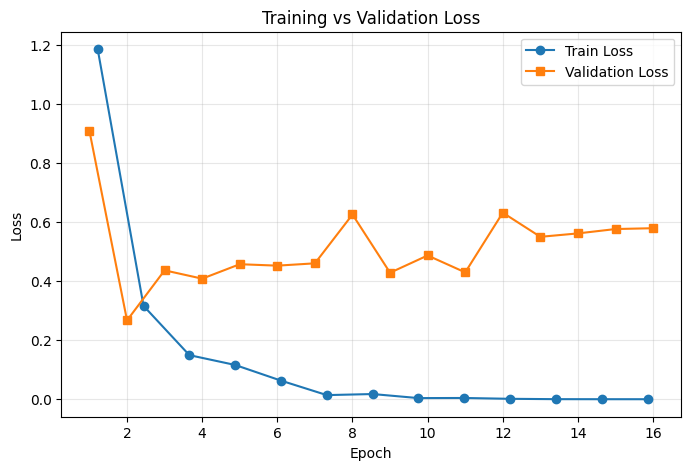

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(train_logs["epoch"], train_logs["loss"],
         marker='o', label='Train Loss')

plt.plot(eval_logs["epoch"], eval_logs["eval_loss"],
         marker='s', label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

stage 1

In [ ]:
res_train_s1 = evaluate_split(trainer_s1, ds_train_s1, 'Stage1 (biner) TRAIN')
res_val_s1   = evaluate_split(trainer_s1, ds_val_s1,   'Stage1 (biner) VALIDATION')
res_test_s1  = evaluate_split(trainer_s1, ds_test_s1,  'Stage1 (biner) TEST')

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.015088,0.088312,8,0.986436,0.986535,0.986436,0.986295


Stage1 (biner) TRAIN
  eval_accuracy: 0.9864
  eval_precision: 0.9865
  eval_recall: 0.9864
  eval_f1: 0.9863


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.015088,0.048052,8,0.994253,0.994294,0.994253,0.994222


Stage1 (biner) VALIDATION
  eval_accuracy: 0.9943
  eval_precision: 0.9943
  eval_recall: 0.9943
  eval_f1: 0.9942


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.015088,0.050106,8,0.988506,0.988670,0.988506,0.988383


Stage1 (biner) TEST
  eval_accuracy: 0.9885
  eval_precision: 0.9887
  eval_recall: 0.9885
  eval_f1: 0.9884


stage 2

In [ ]:
res_train_s2 = evaluate_split(trainer_s2, ds_train_s2, 'Stage2 (liga) TRAIN')
res_val_s2   = evaluate_split(trainer_s2, ds_val_s2,   'Stage2 (liga) VALIDATION')
res_test_s2  = evaluate_split(trainer_s2, ds_test_s2,  'Stage2 (liga) TEST')

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000391,0.001135,16,1.000000,1.000000,1.000000,1.000000


Stage2 (liga) TRAIN
  eval_accuracy: 1.0000
  eval_precision: 1.0000
  eval_recall: 1.0000
  eval_f1: 1.0000


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000391,0.429841,16,0.935252,0.936089,0.935252,0.934675


Stage2 (liga) VALIDATION
  eval_accuracy: 0.9353
  eval_precision: 0.9361
  eval_recall: 0.9353
  eval_f1: 0.9347


Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.000391,0.215031,16,0.963768,0.964147,0.963768,0.963660


Stage2 (liga) TEST
  eval_accuracy: 0.9638
  eval_precision: 0.9641
  eval_recall: 0.9638
  eval_f1: 0.9637


In [ ]:
pipe_s1 = pipeline('text-classification', model='./best_model_stage1',
                    tokenizer='./best_model_stage1', device=0)
pipe_s2 = pipeline('text-classification', model='./best_model_stage2',
                    tokenizer='./best_model_stage2', device=0)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [ ]:
def predict_2stage(text):
    pred_s1 = pipe_s1(text, truncation=True, max_length=128)[0]['label']
    if pred_s1 == 'Sepak bola':
        pred_s2 = pipe_s2(text, truncation=True, max_length=256)[0]['label']
        return pred_s2
    else:
        return 'Non sepak bola'

In [ ]:
texts_test = test_df['text_clean'].tolist()
y_pred_2s = [predict_2stage(t) for t in tqdm(texts_test)]
y_true_str = test_df['label'].tolist()

y_pred_2s_id = [LABEL2ID_5.get(p, -1) for p in y_pred_2s]
y_true_1s_id = [LABEL2ID_5[t] for t in y_true_str]

  0%|          | 0/174 [00:00<?, ?it/s]

In [ ]:
print(classification_report(y_true_1s_id, y_pred_2s_id, target_names=list(LABEL2ID_5.keys())))

                precision    recall  f1-score   support

Non sepak bola       1.00      0.94      0.97        36
   Liga italia       0.94      0.97      0.96        34
Liga indonesia       0.92      1.00      0.96        34
  Liga spanyol       0.97      0.94      0.96        35
  Liga inggris       0.97      0.94      0.96        35

      accuracy                           0.96       174
     macro avg       0.96      0.96      0.96       174
  weighted avg       0.96      0.96      0.96       174



- Non Sepak Bola memperoleh precision sebesar 1,00, recall sebesar 0,94, dan F1-score sebesar 0,97. Nilai precision yang sempurna menunjukkan seluruh prediksi Non Sepak Bola yang dihasilkan model adalah benar, namun recall sebesar 0,94 menunjukkan masih terdapat beberapa berita Non Sepak Bola yang salah diklasifikasikan ke kelas lain

- Liga Italia memperoleh precision sebesar 0,94, recall sebesar 0,97, dan F1-score sebesar 0,96. Hasil ini menunjukkan bahwa sebagian besar berita Liga Italia berhasil dikenali oleh model, meskipun masih terdapat sedikit berita dari kelas lain yang diprediksi sebagai Liga Italia

- Liga Indonesia memperoleh precision sebesar 0,92, recall sebesar 1,00, dan F1-score sebesar 0,96. Nilai recall yang sempurna menunjukkan seluruh berita Liga Indonesia berhasil dikenali oleh model, namun precision yang lebih rendah mengindikasikan masih terdapat beberapa berita dari kelas lain yang salah diklasifikasikan sebagai Liga Indonesia

- Liga Spanyol memperoleh precision sebesar 0,97, recall sebesar 0,94, dan F1-score sebesar 0,96. Hasil ini menunjukkan bahwa model mampu mengklasifikasikan sebagian besar berita Liga Spanyol dengan baik, meskipun masih terdapat sejumlah kecil berita Liga Spanyol yang diprediksi ke kelas lain

- Liga Inggris memperoleh precision sebesar 0,97, recall sebesar 0,94, dan F1-score sebesar 0,96. Nilai precision dan recall yang relatif seimbang menunjukkan bahwa model memiliki kemampuan yang konsisten dalam mengenali berita Liga Inggris dengan tingkat kesalahan klasifikasi yang rendah

- Accuracy model mencapai 0,96, yang menunjukkan bahwa 96% dari total 174 data uji berhasil diklasifikasikan dengan benar. Nilai ini menunjukkan bahwa model klasifikasi dua tahap (two-stage classification) memiliki performa yang sangat baik dalam mengelompokkan berita ke dalam kategori yang sesuai

- Macro Average memperoleh nilai precision, recall, dan F1-score sebesar 0,96, yang menunjukkan bahwa performa model relatif merata pada seluruh kelas. Hal ini mengindikasikan bahwa kemampuan model dalam mengklasifikasikan setiap kategori tidak memiliki perbedaan yang signifikan

- Weighted Average juga memperoleh nilai 0,96 untuk precision, recall, dan F1-score. Kesamaan nilai weighted average dengan macro average menunjukkan bahwa distribusi jumlah data pada setiap kelas relatif seimbang sehingga tidak terdapat kelas yang memberikan pengaruh dominan terhadap hasil evaluasi.

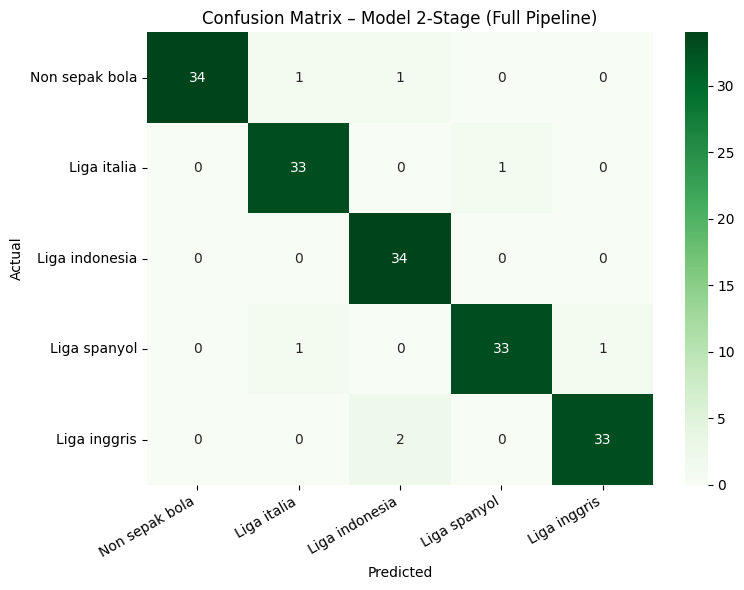

In [ ]:
cm_2s = confusion_matrix(y_true_1s_id, y_pred_2s_id)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_2s, annot=True, fmt='d', cmap='Greens',
            xticklabels=LABEL2ID_5.keys(), yticklabels=LABEL2ID_5.keys())
plt.title('Confusion Matrix – Model 2-Stage (Full Pipeline)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('cm_2stage.png', dpi=150)
plt.show()

# Comparison + Analysis

- Performa Keseluruhan : Model 1 mencapai Accuracy=0.9713, Weighted F1=0.9711, sedangkan Model 2 (Stage 1 + Stage 2) menghasilkan Accuracy=0.9600, Weighted F1=0.9600. Model 1 unggul tipis walaupun arsitektur lebih sederhana, menunjukkan bahwa tambahan kompleksitas model tidak selalu meningkatkan performa

- Overfitting pada Model 2 Stage 2 : Stage 2 Model 2 menunjukkan overfitting yang jelas di mana F1=1.0000 namun validation turun ke 0.9347 dan test ke 0.9637. Hal ini terjadi karena data training Stage 2 lebih sedikit (~451 sampel hanya kelas sepak bola) untuk membedakan 4 liga, dibanding Model 1 yang belajar dari ~811 sampel sekaligus

- Dampak Cascading Error Model 2 : Model 2 Stage 1 sendiri sudah sangat baik (Test F1=0.9884), namun ketika dipasang bersama Stage 2 performa end-to-end turun menjadi 0.9600. Hal ini mengonfirmasi bahwa error dari stage 1 meskipun kecil terbawa ke stage 2 sehingga mengurangi performa akhir

- Kelas Tersulit adalah Liga Inggris. Pada Model 1, Liga Inggris memiliki recall terendah (0.91) dibanding kelas lain yang mencapai 0.97-1.00, artinya ada beberapa artikel Liga Inggris yang salah diprediksi ke kelas liga lain. Pada Model 2  (Stage 1 + Stage 2), recall Liga Inggris juga 0.94 dan relatif setara dengan Liga Spanyol serta Italia (0.94). Hal ini sejalan dengan hasil eda sebelumnya dimana similarity tinggi

- Konvergensi training cukup cepat : Model 1 berhenti di epoch 11 dengan training loss=0.2175, sedangkan Model 2 Stage 1 berhenti di epoch 8 (training loss=0.0760) dan Stage 2 di epoch 16 (training loss=0.1429)

- Hyperparameter Tuning : Model 1 memilih LR=2e-5 dengan batch=8 (val F1=0.9361) karena learning rate sedang menghindari pembaruan parameter yang terlalu besar pada data 5 kelas yang lebih beragam, sementara Model 2 Stage 1 memilih LR=3e-5 batch=8 (val F1=0.9885) dan Stage 2 memilih LR=3e-5 batch=16 (val F1=0.9279). LR lebih besar ini karena keduanya membutuhkan melakukan tugas yang lebih spesifik (biner dan 4 liga) memungkinkan konvergensi lebih cepat dengan langkah yang lebih besar

# Conclusion

- Model 1 Lebih Unggul secara End-to-End : Model 1 (1-Stage) menghasilkan Weighted F1=0.9711 pada test set, lebih tinggi dibanding Model 2 yang hanya 0.9600 secara end-to-end, sehingga Model 1 lebih direkomendasikan karena lebih akurat, lebih efisien (satu model), dan bebas dari risiko cascading error.

- Performa model sangat bergantung pada data : semakin banyak jumlah data, semakin baik kemampuan generalisasi model. Performa model bisa ditingkatkan lagi dengan menambahkan artikel dan melakukan hyperparameter lebih. Selain itu, sumber data yang lebih bersih lagi juga dapat meningkatkan performa model

- Keterbatasan Data Kecil  : Jumlah data yang sedikit (~120 artikel per kelas) membuat model overfitting, terutama Model 2 Stage 2  yang mengalami overfitting parah (train F1=1.0, val F1=0.93), karena hanya ~451 sampel tersisa untuk melatih 4 kelas liga


- Keterbatasan Data Noisy : Proses data cleaning tidak mungkin sepenuhnya bersih karena selalu ada konten dinamis yang lolos dari  regex yang sudah dibuat. Tingkat kebersihan yang lebih optimal sangat bergantung pada karakteristik sumber data


VIDEO : https://binusianorg-my.sharepoint.com/personal/glenn_laymando_binus_ac_id/_layouts/15/guestaccess.aspx?share=IgDo0f28e5i7QasPWSgxCE6uAQ2WrjUjWUh9uhh3tXn8HwI&e=71uZRQ